In [55]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [56]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from sklearn.metrics import f1_score, confusion_matrix
import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from collections import Counter
import os
import glob
import pyedflib
import yaml
import json
import h5py
import numpy as np
import pandas as pd
import datetime
from tqdm import tqdm
import multiprocessing
from loguru import logger
import warnings
from scipy.signal import butter, filtfilt, resample
import mne
sys.path.append("..")
sys.path.append("../sleepfm")
"""from preprocessing.preprocessing import EDFToHDF5Converter"""
from models.dataset import SetTransformerDataset, collate_fn
from models.models import SetTransformer, SleepEventLSTMClassifier, DiagnosisFinetuneFullLSTMCOXPHWithDemo
from utils import load_config, load_data, save_data, count_parameters
from torch.utils.data import Dataset, DataLoader
import torch
from torch import nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
device = torch.device("cuda")
print(device)

cuda


In [57]:
class EDFToHDF5Converter:
    def __init__(self, root_dir, target_dir, resample_rate=512, num_threads=1, num_files=-1, channels=None):
        self.resample_rate = resample_rate 
        self.root_dir = root_dir
        self.target_dir = target_dir
        self.num_threads = num_threads
        self.num_files = num_files
        self.channels = channels
        self.file_locations = self.get_files() 
        # self.scorers = ['ES','LS','MS']
        self.flow_events = {'Central Apnea': 1, 'Mixed Apnea': 2, 'Obstructive Apnea': 3, 'Hypopnea': 4, 'RERA': 5}
        self.plm_events = {'P-Marker': 1, 'I-Marker': 2, 'LM Body position': 3, 'LM Resp': 4}
        self.arousal_events = {'Autonomic arousals': 1, 'Respiratory Arousal': 2}
        self.sleep_stages = {'Wake': 0, 'Rem': 1, 'N1': 2, 'N2': 3, 'N3': 4, 'Artifact': 5}


    def get_files(self):
        # Search for all '.edf' files within each subdirectory of the root directory
        file_paths = glob.glob(os.path.join(self.root_dir, '**/*.[eE][dD][fF]'), recursive=True)
        file_names = [os.path.basename(path) for path in file_paths]
        return file_paths, file_names
    
    def extract_start_time(self, file_path):
        with open(file_path, 'r') as file:
            lines = [next(file) for _ in range(5)]
            
        for line in lines:
            if line.startswith("Start Time:"):
                return line.split(": ", 1)[1].strip()
        return "Start Time not found"

    def create_signal_from_events(self, df, total_seconds, event_type = None):
        valid_types = {'flow', 'plm', 'arousal','stages'}
        if event_type not in valid_types:
            raise ValueError("event_type must be 'flow', 'plm', or 'arousal'")
        
        total_samples = int(total_seconds * self.resample_rate)
        # make initial array of zeros with length total_sec
        event_array = np.zeros(total_samples)

        # go through each event and mark the corresponding seconds in the array
        for _, row in df.iterrows():
            event_start = int(row['sec_from_start'] * self.resample_rate)
            event_stop = int(row['sec_from_start'] * self.resample_rate + row['dur'] * self.resample_rate)
            if event_type == 'flow':
                event_code = self.flow_events.get(row['event_type'], 0)
            elif event_type == 'plm':
                event_code = self.plm_events.get(row['event_type'], 0)
            elif event_type == 'arousal':
                event_code = self.arousal_events.get(row['event_type'], 0)
            elif event_type == 'stages':
                event_code = self.sleep_stages.get(row['event_type'])
            
            event_array[event_start:event_stop] = event_code
        
        return event_array

    def make_event_dataframe(self, folder, event_type = None):
        valid_types = {'flow', 'plm', 'arousal','stages'}
        if event_type not in valid_types:
            raise ValueError("event_type must be 'flow', 'plm', or 'arousal'")
        if event_type == 'flow':
            flow_file = os.path.join(self.root_dir,folder,'Flow Events.txt')
            df = pd.read_csv(flow_file, delimiter=';',skiprows=5, names=['start-stop', 'duration', 'event_type'])
        elif event_type == 'plm':
            flow_file = os.path.join(self.root_dir,folder,'PLM Events.txt')
            df = pd.read_csv(flow_file, delimiter=';',skiprows=5, names=['start-stop', 'duration', 'event_type'])
        elif event_type == 'arousal':
            flow_file = os.path.join(self.root_dir,folder,'Autonomic arousals.txt')
            dfAutonomic = pd.read_csv(flow_file, delimiter=';',skiprows=5, names=['start-stop', 'duration', 'event_type'])
            flow_file = os.path.join(self.root_dir,folder,'Classification arousals.txt')
            dfClassification = pd.read_csv(flow_file, delimiter=';',skiprows=5, names=['start-stop', 'duration', 'event_type'])
            df = pd.concat([dfAutonomic,dfClassification], ignore_index=True)
        elif event_type == 'stages':
            flow_file1 = os.path.join(self.root_dir,folder,'Flow Events.txt')
            start_time = self.extract_start_time(file_path = flow_file1)
            start_time = datetime.datetime.strptime(start_time, "%m/%d/%Y %I:%M:%S %p")
            flow_file = os.path.join(self.root_dir,folder,'Sleep profile.txt')
            df = pd.read_csv(flow_file, delimiter=';',skiprows=7, names=['start', 'event_type']) 
            df['start'] = pd.to_datetime(df['start'], format='%H:%M:%S,%f').dt.time
            df['sec_from_start'] = df['start'].apply(lambda x: (datetime.datetime.combine(datetime.date(1,1,1),x) - datetime.datetime.combine(datetime.date(1,1,1),start_time.time())).total_seconds())
            df['dur'] = 30
            df['event_type'] = df['event_type'].str.strip()
            if df['sec_from_start'].iloc[0] < 0:
                df['dur'][0] = 30 + df['sec_from_start'].iloc[0]
                df['sec_from_start'].iloc[0] = 0
            df.loc[df.sec_from_start < 0, 'sec_from_start'] += 24*60*60
            return df

        # df = pd.read_csv(flow_file, delimiter=';',skiprows=5, names=['start-stop', 'duration', 'event_type'])
        if len(df.values) != 0:
            df[['start', 'stop']] = df['start-stop'].str.split('-', expand=True)

            start_time = self.extract_start_time(file_path = flow_file)
            start_time = datetime.datetime.strptime(start_time, "%m/%d/%Y %I:%M:%S %p")

            df['start'] = pd.to_datetime(df['start'], format='%H:%M:%S,%f').dt.time
            df['stop'] = pd.to_datetime(df['stop'], format='%H:%M:%S,%f').dt.time
            df['sec_from_start'] = df['start'].apply(lambda x: (datetime.datetime.combine(datetime.date(1,1,1),x) - datetime.datetime.combine(datetime.date(1,1,1),start_time.time())).total_seconds())
            df['sec_from_stop'] = df['stop'].apply(lambda x: (datetime.datetime.combine(datetime.date(1,1,1),x) - datetime.datetime.combine(datetime.date(1,1,1),start_time.time())).total_seconds())

            df['duration'] = pd.to_numeric(df['duration'])

            df = df[['start', 'stop', 'duration', 'event_type', 'sec_from_start','sec_from_stop']]

            df.loc[df.sec_from_start < 0, 'sec_from_start'] += 24*60*60
            df.loc[df.sec_from_stop < 0, 'sec_from_stop'] += 24*60*60
            df['dur'] = df['sec_from_stop'] - df['sec_from_start']
        else:
            df  = pd.DataFrame(columns = ['start', 'stop', 'duration', 'event_type', 'sec_from_start','sec_from_stop', 'dur'])

        return df

    def convert_events(self, folder,total_seconds,event_type):
        df_events = self.make_event_dataframe(folder, event_type=event_type)
        event_array = self.create_signal_from_events(df=df_events, total_seconds=total_seconds, event_type=event_type)
        return event_array

    def read_edf_old(self, file_path):
        logger.info('reading edf')
        with pyedflib.EdfReader(file_path) as edf:
            signals = [edf.readSignal(i) for i in range(edf.signals_in_file)]
            sample_rates = np.array([edf.getSampleFrequency(i) for i in range(edf.signals_in_file)])
            channel_names = np.array([edf.getLabel(i) for i in range(edf.signals_in_file)])
            # annotations = []#edf.readAnnotations()
        return signals, sample_rates, channel_names
    
    def read_edf(self, file_path):
        logger.info(f'Reading EDF: {os.path.basename(file_path)}')
        
        try:
            # Charger avec filtrage de canaux si spécifié
            if self.channels is not None and len(self.channels) > 0:
                # Vérifier d'abord quels canaux existent
                logger.info(f'Checking available channels...')
                raw_temp = mne.io.read_raw_edf(file_path,include=self.channels, preload=False, verbose=False)
                
                available_channels = [ch for ch in self.channels if ch in raw_temp.ch_names]
                missing_channels = set(self.channels) - set(available_channels)
                
                if missing_channels:
                    logger.warning(f"⚠️  Canaux manquants: {missing_channels}")
                
                if not available_channels:
                    raise ValueError(f"❌ Aucun des canaux spécifiés n'a été trouvé dans {file_path}\n"
                                f"   Canaux demandés: {self.channels}\n"
                                f"   Canaux disponibles: {raw_temp.ch_names}")
                
                logger.info(f'✅ Chargement de {len(available_channels)}/{len(self.channels)} canaux')
                raw = mne.io.read_raw_edf(file_path, include=available_channels, preload=True, verbose=False)
            else:
                # Charger tous les canaux si aucun filtre spécifié
                logger.info('Loading all channels (no filter specified)')
                raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
            
            # Extraire les données
            signals = [raw.get_data(picks=[ch_name])[0] for ch_name in raw.ch_names]
            sample_rates = np.array([raw.info['sfreq'] for _ in raw.ch_names])
            channel_names = np.array(raw.ch_names)
            
            logger.info(f'✅ Loaded {len(channel_names)} channels, {len(signals[0])} samples at {sample_rates[0]} Hz')
            
            return signals, sample_rates, channel_names
            
        except Exception as e:
            logger.error(f"❌ Error reading {file_path}: {str(e)}")
            raise

    def resample_signals_old(self, signals, sample_rates):
        # Vectorization and broadcasting could be applied within the resample function itself
        logger.info('resampling signals')
        resampled_signals = [resample(signal, int(len(signal) * self.resample_rate / rate))
                             for signal, rate in zip(signals, sample_rates)]
        standardized_signals = [(signal - np.mean(signal)) / np.std(signal) for signal in resampled_signals]
        # add signal names as input and filter the spo2 preprocessing as scaled 0 to 1
        return np.stack(standardized_signals)# Using np.stack for proper array dimensions


    def safe_standardize(self, signal):
        mean = np.mean(signal)
        std = np.std(signal)
        
        if std == 0:
            standardized_signal = (signal - mean)
        else:
            standardized_signal = (signal - mean) / std
        
        return standardized_signal
        
    def filter_signal(self, signal, sample_rate):
        print("Filtering signal")
        nyquist_freq = sample_rate / 2
        cutoff = min(self.resample_rate / 2, nyquist_freq)
        normalized_cutoff = cutoff / nyquist_freq
        b, a = butter(4, normalized_cutoff, btype='low', analog=False)
        filtered_signal = filtfilt(b, a, signal)
        return filtered_signal

    def resample_signals(self, signals, sample_rates):
        logger.info('resampling signals')
        resampled_signals = []
        for signal, rate in zip(signals, sample_rates):
            # Calculate the duration of the signal
            duration = len(signal) / rate
            
            # Original time points
            original_time_points = np.linspace(0, duration, num=len(signal), endpoint=False)
            
            # New sample rate and new time points
            new_sample_count = int(duration * self.resample_rate)
            new_time_points = np.linspace(0, duration, num=new_sample_count, endpoint=False)

            #filter signal
            if rate > self.resample_rate:
                signal = self.filter_signal(signal, rate)
            
            # Linear interpolation
            resampled_signal = np.interp(new_time_points, original_time_points, signal)
            
            # Standardize the resampled signal (optional, based on your need)
            # standardized_signal = (resampled_signal - np.mean(resampled_signal)) / np.std(resampled_signal)
            standardized_signal = self.safe_standardize(resampled_signal)
            
            if np.isnan(standardized_signal).any():
                logger.info('Found NaN in the resampled signal.')
                # Handle the NaN case here (e.g., skip or fix the signal)
                continue

            resampled_signals.append(standardized_signal)

        
        return np.stack(resampled_signals)  # Stack for a consistent output format

    def save_to_hdf5(self, signals, channel_names, annotation_signals, annotation_names, file_path):
        logger.info('saving hdf5')
        samples_per_chunk = 5 * 60 * self.resample_rate
        with h5py.File(file_path, 'w') as hdf:
            for signal, name in zip(signals, channel_names):
                dataset_name = self._get_unique_name(hdf, name)
                hdf.create_dataset(dataset_name, data=signal,
                                   dtype='float16', chunks=(samples_per_chunk,), compression="gzip")

            for annot_signal, annot_name in zip(annotation_signals, annotation_names):
                hdf.create_dataset(annot_name, data=annot_signal)

    def _get_unique_name(self, hdf, base_name):
        # Helper method to ensure dataset names are unique
        i = 1
        unique_name = base_name
        while unique_name in hdf:
            unique_name = f"{base_name}_{i}"
            i += 1
        return unique_name

    def get_annotations(self, total_seconds, folder):
        # folder_path = 'C:/Users/45223/OneDrive - Danmarks Tekniske Universitet/PhD/Oliver_triple_scored/triple_scored_studies1/CSA009/ES'
        flow_events = self.convert_events(folder = folder, total_seconds = total_seconds, event_type = 'flow')
        plm_events = self.convert_events( folder = folder, total_seconds = total_seconds, event_type = 'plm')
        arousal_events = self.convert_events( folder = folder, total_seconds = total_seconds, event_type = 'arousal')
        sleep_stages = self.convert_events( folder = folder, total_seconds = total_seconds, event_type = 'stages')

        return flow_events, plm_events, arousal_events, sleep_stages
    
    def convert(self, edf_path, hdf5_path):
        signals, sample_rates, channel_names = self.read_edf(edf_path)
        resampled_signals = self.resample_signals(signals, sample_rates)
        total_duration_seconds = len(signals[0])/sample_rates[0]
        event_signals = []
        event_signal_names = []
        self.save_to_hdf5(resampled_signals, channel_names,event_signals,event_signal_names, hdf5_path)

    def convert_multiprocessing(self, args):
        edf_files = args

        for edf_file in tqdm(edf_files, desc="Converting EDF files"):

            if edf_file.endswith(".edf"):
                replace_str = ".edf"
            elif edf_file.endswith(".EDF"):
                replace_str = ".EDF"
            hdf5_file = os.path.join(self.target_dir, edf_file.split('/')[-1].replace(replace_str, '.hdf5'))

            if os.path.exists(hdf5_file):
                logger.info(f"File already processed: {hdf5_file}")
                continue
            try:
                self.convert(edf_file, hdf5_file)
            except Exception as e:
                warnings.warn(f"Warning: Could not process the file {edf_file}. Error: {str(e)}")
                continue
        return [1]

    def convert_all(self):
        edf_files, edf_names = self.get_files() 
        # folders = self.get_folders()
        for edf_file in tqdm(edf_files, desc="Converting EDF files"):
            # edf_files = [os.path.join(folder, f) for f in os.listdir(os.path.join(self.root_dir,folder)) if f.endswith('.edf')]
            # edf_file = os.path.join(self.root_dir,edf_files[0])
            if edf_file.endswith(".edf"):
                replace_str = ".edf"
            elif edf_file.endswith(".EDF"):
                replace_str = ".EDF"
            hdf5_file = os.path.join(self.target_dir,edf_file.split('/')[-1].replace(replace_str, '.hdf5'))
            # logger.info(edf_file)
            # logger.info(hdf5_file)

            try:
                self.convert(edf_file, hdf5_file)
            except Exception as e:
                warnings.warn(f"Warning: Could not process the file {edf_file}. Error: {str(e)}")
                continue

    def convert_all_multiprocessing(self):
        edf_files, edf_names = self.get_files() 

        if self.num_files != -1:
            edf_files = edf_files[:self.num_files]

        edf_files_chunks = np.array_split(edf_files, self.num_threads)
        tasks = [(edf_files_chunk) for edf_files_chunk in edf_files_chunks]
        with multiprocessing.Pool(self.num_threads) as pool:
            preprocessed_results = [y for x in pool.imap_unordered(self.convert_multiprocessing, tasks) for y in x]

    def convert_with_annot(self, edf_path, hdf5_path, folder):
        signals, sample_rates, channel_names = self.read_edf(edf_path)
        resampled_signals = self.resample_signals(signals, sample_rates)
        total_duration_seconds = len(signals[0])/sample_rates[0]
        event_signals = []
        event_signal_names = []
        for scorer in self.scorers:
            scorer_folder = os.path.join(folder, scorer) 
            flow_events, plm_events, arousal_events, sleep_stages = self.get_annotations(total_seconds = total_duration_seconds, folder = scorer_folder)
            event_signals.extend([flow_events, plm_events, arousal_events, sleep_stages])
            event_signal_names.extend(['flow_events'+scorer, 'plm_events'+scorer, 'arousal_events'+scorer, 'sleep_stages'+scorer])
        self.save_to_hdf5(resampled_signals, channel_names,event_signals,event_signal_names, hdf5_path)

    def convert_all_with_annot(self):
        edf_files, edf_names = self.get_files() 
        folders = self.get_folders()
        for folder in tqdm(folders, desc="Converting EDF files"):
            edf_files = [os.path.join(folder, f) for f in os.listdir(os.path.join(self.root_dir,folder)) if f.lower().endswith('.edf')]
            edf_file = os.path.join(self.root_dir,edf_files[0])
            # header = self.extract_end_time(edf_file)
            # hdf5_file = os.path.join(self.root_dir, edf_file.replace('.edf', '.hdf5'))
            if edf_file.endswith(".edf"):
                replace_str = ".edf"
            elif edf_file.endswith(".EDF"):
                replace_str = ".EDF"
            hdf5_file = os.path.join(self.target_dir,edf_file.split('\\')[-1].replace(replace_str, '.hdf5'))

            # logger.info(hdf5_file)
            self.convert_with_annot(edf_file, hdf5_file, folder)
    def plot_results(self, resampled_signals, channel_names):
        print("plotting resampled_signals")
        num_signals = len(resampled_signals)
        fig, axs = plt.subplots(num_signals, 1, figsize=(15, 3*num_signals), sharex=True)
        samples_to_plot = 10 * self.resample_rate
        sample_to_start = 10 * self.resample_rate
        for i, (signal, name) in enumerate(zip(resampled_signals, channel_names)):
            signal_chunk = signal[sample_to_start:sample_to_start+samples_to_plot]
            axs[i].plot(signal_chunk)
            axs[i].set_title(name)
            axs[i].set_ylabel('Amplitude')
        
        axs[-1].set_xlabel('Samples')
        plt.tight_layout()
        plt.show()

    def plot_first_results(self, resampled_signals, channel_names):
        print("plotting resampled_signals")
        num_signals = len(resampled_signals)
        fig = plt.figure(figsize=(15, 3))
        samples_to_plot = 10 * self.resample_rate
        sample_to_start = 10 * self.resample_rate
        for i, (signal, name) in enumerate(zip(resampled_signals, channel_names)):
            signal_chunk = signal[sample_to_start:sample_to_start+samples_to_plot]
            plt.plot(signal_chunk)
            plt.title(name)
            plt.ylabel('Amplitude')
            break
        
        plt.xlabel('Samples')
        plt.tight_layout()
        plt.show()

    def process_and_plot_single_file(self, edf_path):
        signals, sample_rates, channel_names = self.read_edf(edf_path)
        resampled_signals = self.resample_signals(signals, sample_rates)
        #self.plot_results(resampled_signals, channel_names)
        self.plot_first_results(resampled_signals, channel_names)
    

In [58]:
CHANNEL_GROUPS = {
    "EEG": ["Fp1", "C3", "O1", "C4"],       
    "EOG": ["EOG G", "EOG D"],
    "EMG": ["EMG 1", "EMG 2"],          
    "EKG": ["ECG"],
    "REF": ["A2"],   
    "RESP": ["Thermistance", "Flow",]                   
}
CHANNEL_OI = sorted({ch for grp in CHANNEL_GROUPS.values() for ch in grp})

CATEGORY_MAPPING = {
    "EEG": "BAS",
    "EOG": "BAS",
    "REF": "BAS",
    "ECG": "EKG",
    "EMG": "EMG",
    "RESP": "RESP",
    "EKG": "EKG"
}
CHANNEL_GROUPS_FOR_MODEL = {'BAS': [], 'EKG': [], 'RESP': [], 'EMG': []}

for category, channels in CHANNEL_GROUPS.items():
    model_category = CATEGORY_MAPPING.get(category, 'BAS')
    CHANNEL_GROUPS_FOR_MODEL[model_category].extend(channels)
print(CHANNEL_GROUPS_FOR_MODEL)

{'BAS': ['Fp1', 'C3', 'O1', 'C4', 'EOG G', 'EOG D', 'A2'], 'EKG': ['ECG'], 'RESP': ['Thermistance', 'Flow'], 'EMG': ['EMG 1', 'EMG 2']}


In [59]:

from glob import glob
model_path = "../sleepfm/checkpoints/model_base"
channel_groups_path = "../sleepfm/configs/channel_groups.json"
config_path = os.path.join(model_path, "config.json")

config = load_config(config_path)
modality_types = config["modality_types"]
in_channels = config["in_channels"]
patch_size = config["patch_size"]
embed_dim = config["embed_dim"]
num_heads = config["num_heads"]
num_layers = config["num_layers"]
pooling_head = config["pooling_head"]
dropout = 0.0

print(f"CUDA disponible: {torch.cuda.is_available()}")
print(f"Version PyTorch: {torch.__version__}")

model_class = getattr(sys.modules[__name__], config['model'])
model = model_class(in_channels, patch_size, embed_dim, num_heads, num_layers, pooling_head=pooling_head, dropout=dropout)

device = torch.device("cuda")
print(device)

if device.type == "cuda":
    model = torch.nn.DataParallel(model)

model.to(device)

model.eval()

hdf5_paths = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_data"
hdf5_files = glob(os.path.join(hdf5_paths, "*.hdf5"))

dataset = SetTransformerDataset(config, CHANNEL_GROUPS_FOR_MODEL , hdf5_paths=hdf5_files, split="test")
dataloader = torch.utils.data.DataLoader(dataset, 
                                            batch_size=16, 
                                            num_workers=1, 
                                            shuffle=False, 
                                            collate_fn=collate_fn)

output = os.path.join(hdf5_paths, "train_emb_hazard")
output_5min_agg = os.path.join(hdf5_paths, "train_emb__hazard_5min_agg")
os.makedirs(output, exist_ok=True)
os.makedirs(output_5min_agg, exist_ok=True)
with torch.no_grad():
    with tqdm(total=len(dataloader)) as pbar:
        for batch in dataloader:
            batch_data, mask_list, file_paths, dset_names_list, chunk_starts = batch
            (bas, resp, ekg, emg) = batch_data
            (mask_bas, mask_resp, mask_ekg, mask_emg) = mask_list

            bas = bas.to(device, dtype=torch.float)
            resp = resp.to(device, dtype=torch.float)
            ekg = ekg.to(device, dtype=torch.float)
            emg = emg.to(device, dtype=torch.float)

            mask_bas = mask_bas.to(device, dtype=torch.bool)
            mask_resp = mask_resp.to(device, dtype=torch.bool)
            mask_ekg = mask_ekg.to(device, dtype=torch.bool)
            mask_emg = mask_emg.to(device, dtype=torch.bool)

            embeddings = [
                model(bas, mask_bas),
                model(resp, mask_resp),
                model(ekg, mask_ekg),
                model(emg, mask_emg),
            ]
            # Model gives two kinds of embeddings. Granular 5 second-level embeddings and aggregated 5 minute-level embeddings. We save both of them below. 

            embeddings_new = [e[0].unsqueeze(1) for e in embeddings]

            for i in range(len(file_paths)):
                file_path = file_paths[i]
                chunk_start = chunk_starts[i]
                subject_id = os.path.basename(file_path).split('.')[0]
                output_path = os.path.join(output_5min_agg, f"{subject_id}.hdf5")

                with h5py.File(output_path, 'a') as hdf5_file:
                    for modality_idx, modality_type in enumerate(config["modality_types"]):
                        if modality_type in hdf5_file:
                            dset = hdf5_file[modality_type]
                            chunk_start_correct = chunk_start // (embed_dim * 5 * 60)
                            chunk_end = chunk_start_correct + embeddings_new[modality_idx][i].shape[0]
                            if dset.shape[0] < chunk_end:
                                dset.resize((chunk_end,) + embeddings_new[modality_idx][i].shape[1:])
                            dset[chunk_start_correct:chunk_end] = embeddings_new[modality_idx][i].cpu().numpy()
                        else:
                            hdf5_file.create_dataset(modality_type, data=embeddings_new[modality_idx][i].cpu().numpy(), chunks=(embed_dim,) + embeddings_new[modality_idx][i].shape[1:], maxshape=(None,) + embeddings_new[modality_idx][i].shape[1:])

            embeddings_new = [e[1] for e in embeddings]

            for i in range(len(file_paths)):
                file_path = file_paths[i]
                chunk_start = chunk_starts[i]
                subject_id = os.path.basename(file_path).split('.')[0]
                output_path = os.path.join(output, f"{subject_id}.hdf5")

                with h5py.File(output_path, 'a') as hdf5_file:
                    for modality_idx, modality_type in enumerate(config["modality_types"]):
                        if modality_type in hdf5_file:
                            dset = hdf5_file[modality_type]
                            chunk_start_correct = chunk_start // (embed_dim * 5)
                            chunk_end = chunk_start_correct + embeddings_new[modality_idx][i].shape[0]
                            if dset.shape[0] < chunk_end:
                                dset.resize((chunk_end,) + embeddings_new[modality_idx][i].shape[1:])
                            dset[chunk_start_correct:chunk_end] = embeddings_new[modality_idx][i].cpu().numpy()
                        else:
                            hdf5_file.create_dataset(modality_type, data=embeddings_new[modality_idx][i].cpu().numpy(), chunks=(embed_dim,) + embeddings_new[modality_idx][i].shape[1:], maxshape=(None,) + embeddings_new[modality_idx][i].shape[1:])
            pbar.update()

CUDA disponible: True
Version PyTorch: 2.5.1+cu121
cuda


c:\Users\gabri\anaconda3\envs\sleepfm_env\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
100%|██████████| 21/21 [00:25<00:00,  1.20s/it]


In [60]:
model_path = "../sleepfm/checkpoints/model_base"
channel_groups_path = "../sleepfm/configs/channel_groups.json"
config_path = os.path.join(model_path, "config.json")

config = load_config(config_path)
modality_types = config["modality_types"]
in_channels = config["in_channels"]
patch_size = config["patch_size"]
embed_dim = config["embed_dim"]
num_heads = config["num_heads"]
num_layers = config["num_layers"]
pooling_head = config["pooling_head"]
dropout = 0.0

In [61]:
print(f"CUDA disponible: {torch.cuda.is_available()}")
print(f"Version PyTorch: {torch.__version__}")
model_class = getattr(sys.modules[__name__], config['model'])
model = model_class(in_channels, patch_size, embed_dim, num_heads, num_layers, pooling_head=pooling_head, dropout=dropout)

device = torch.device("cuda")
print(device)
if device.type == "cuda":
    model = torch.nn.DataParallel(model)

model.to(device)
total_layers, total_params = count_parameters(model)
print(f'Trainable parameters: {total_params / 1e6:.2f} million')
print(f'Number of layers: {total_layers}')

CUDA disponible: True
Version PyTorch: 2.5.1+cu121
cuda
Trainable parameters: 4.44 million
Number of layers: 93


In [62]:
checkpoint = torch.load(os.path.join(model_path, "best.pt"))
model.load_state_dict(checkpoint["state_dict"])
model.eval()

C:\Users\gabri\AppData\Local\Temp\ipykernel_11036\2740997419.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(model_path, "best.pt"))

DataParallel(
  (module): SetTransformer(
    (patch_embedding): Tokenizer(
      (tokenizer): Sequential(
        (0): Conv1d(1, 4, kernel_size=(5,), stride=(2,), padding=(2,))
        (1): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ELU(alpha=1.0)
        (3): LayerNorm((4, 320), eps=1e-05, elementwise_affine=True)
        (4): Conv1d(4, 8, kernel_size=(5,), stride=(2,), padding=(2,))
        (5): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (6): ELU(alpha=1.0)
        (7): LayerNorm((8, 160), eps=1e-05, elementwise_affine=True)
        (8): Conv1d(8, 16, kernel_size=(5,), stride=(2,), padding=(2,))
        (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (10): ELU(alpha=1.0)
        (11): LayerNorm((16, 80), eps=1e-05, elementwise_affine=True)
        (12): Conv1d(16, 32, kernel_size=(5,), stride=(2,), padding=(2,))
        (13): BatchNorm1d(32, eps=1

In [63]:
from glob import glob

In [64]:
hdf5_paths = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_data"
hdf5_files = glob(os.path.join(hdf5_paths, "*.hdf5"))

dataset = SetTransformerDataset(config, CHANNEL_GROUPS_FOR_MODEL , hdf5_paths=hdf5_files, split="test")
dataloader = torch.utils.data.DataLoader(dataset, 
                                            batch_size=16, 
                                            num_workers=1, 
                                            shuffle=False, 
                                            collate_fn=collate_fn)


Indexing files: 100%|██████████| 3/3 [00:05<00:00,  1.99s/it]


Dataloader = (target, file_path, dset_names, chunk_start, self.modalities_length

target : Liste de tenseurs (un par modalité)
file_path : Chemin du fichier source
dset_names : Noms des canaux chargés
chunk_start : Position de départ (pour reconstruction)
modalities_length : Nombre de canaux attendus par modalité)

In [65]:
output = os.path.join(hdf5_paths, "train_emb")
output_5min_agg = os.path.join(hdf5_paths, "train_5min_agg_emb")
os.makedirs(output, exist_ok=True)
os.makedirs(output_5min_agg, exist_ok=True)

In [66]:
with torch.no_grad():
    with tqdm(total=len(dataloader)) as pbar:
        for batch in dataloader:
            batch_data, mask_list, file_paths, dset_names_list, chunk_starts = batch
            (bas, resp, ekg, emg) = batch_data
            (mask_bas, mask_resp, mask_ekg, mask_emg) = mask_list

            bas = bas.to(device, dtype=torch.float)
            resp = resp.to(device, dtype=torch.float)
            ekg = ekg.to(device, dtype=torch.float)
            emg = emg.to(device, dtype=torch.float)

            mask_bas = mask_bas.to(device, dtype=torch.bool)
            mask_resp = mask_resp.to(device, dtype=torch.bool)
            mask_ekg = mask_ekg.to(device, dtype=torch.bool)
            mask_emg = mask_emg.to(device, dtype=torch.bool)

            embeddings = [
                model(bas, mask_bas),
                model(resp, mask_resp),
                model(ekg, mask_ekg),
                model(emg, mask_emg),
            ]
            # Model gives two kinds of embeddings. Granular 5 second-level embeddings and aggregated 5 minute-level embeddings. We save both of them below. 

            embeddings_new = [e[0].unsqueeze(1) for e in embeddings]

            for i in range(len(file_paths)):
                file_path = file_paths[i]
                chunk_start = chunk_starts[i]
                subject_id = os.path.basename(file_path).split('.')[0]
                output_path = os.path.join(output_5min_agg, f"{subject_id}.hdf5")

                with h5py.File(output_path, 'a') as hdf5_file:
                    for modality_idx, modality_type in enumerate(config["modality_types"]):
                        if modality_type in hdf5_file:
                            dset = hdf5_file[modality_type]
                            chunk_start_correct = chunk_start // (embed_dim * 5 * 60)
                            chunk_end = chunk_start_correct + embeddings_new[modality_idx][i].shape[0]
                            if dset.shape[0] < chunk_end:
                                dset.resize((chunk_end,) + embeddings_new[modality_idx][i].shape[1:])
                            dset[chunk_start_correct:chunk_end] = embeddings_new[modality_idx][i].cpu().numpy()
                        else:
                            hdf5_file.create_dataset(modality_type, data=embeddings_new[modality_idx][i].cpu().numpy(), chunks=(embed_dim,) + embeddings_new[modality_idx][i].shape[1:], maxshape=(None,) + embeddings_new[modality_idx][i].shape[1:])

            embeddings_new = [e[1] for e in embeddings]

            for i in range(len(file_paths)):
                file_path = file_paths[i]
                chunk_start = chunk_starts[i]
                subject_id = os.path.basename(file_path).split('.')[0]
                output_path = os.path.join(output, f"{subject_id}.hdf5")

                with h5py.File(output_path, 'a') as hdf5_file:
                    for modality_idx, modality_type in enumerate(config["modality_types"]):
                        if modality_type in hdf5_file:
                            dset = hdf5_file[modality_type]
                            chunk_start_correct = chunk_start // (embed_dim * 5)
                            chunk_end = chunk_start_correct + embeddings_new[modality_idx][i].shape[0]
                            if dset.shape[0] < chunk_end:
                                dset.resize((chunk_end,) + embeddings_new[modality_idx][i].shape[1:])
                            dset[chunk_start_correct:chunk_end] = embeddings_new[modality_idx][i].cpu().numpy()
                        else:
                            hdf5_file.create_dataset(modality_type, data=embeddings_new[modality_idx][i].cpu().numpy(), chunks=(embed_dim,) + embeddings_new[modality_idx][i].shape[1:], maxshape=(None,) + embeddings_new[modality_idx][i].shape[1:])
            pbar.update()

100%|██████████| 21/21 [00:20<00:00,  1.02it/s]


In [67]:
print(embeddings[0][1].shape)
print(embeddings[0][0].shape)

torch.Size([12, 60, 128])
torch.Size([12, 128])


torch.Size([13, 60, 128]) = batch vect de 5min coupé en 60 soit 60 vect de 5s
torch.Size([13, 128]) = batch vect de 5 min

In [68]:
from einops import rearrange

class PositionalEncoding(nn.Module):
    def __init__(self, max_len, d_model):
        super().__init__()
        self.encoding = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)
    
    def forward(self, x):
        B, S, E = x.shape
        return x + self.encoding[:, :S, :]

class AttentionPooling(nn.Module):
    """Pooling spatial avec attention"""
    def __init__(self, embed_dim, num_heads=4, dropout=0.1):
        super().__init__()
        self.transformer_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.query = nn.Parameter(torch.randn(1, 1, embed_dim))
        
    def forward(self, x, mask=None):
        # x: (B, C, E), mask: (B, C)
        B = x.size(0)
        query = self.query.expand(B, -1, -1)  # (B, 1, E)
        
        # Concat query with input
        x = torch.cat([query, x], dim=1)  # (B, 1+C, E)
        
        if mask is not None:
            # Add False for query position
            query_mask = torch.zeros(B, 1, dtype=torch.bool, device=mask.device)
            mask = torch.cat([query_mask, mask], dim=1)
        
        x = self.transformer_layer(x, src_key_padding_mask=mask)
        return x[:, 0, :]  # Return query output

class MultiScaleTemporalBlock(nn.Module):
    """
    Capture des patterns temporels à plusieurs échelles:
    - 5-10s: Micro-éveils, mouvements oculaires rapides
    - 30s-1min: Transitions entre stades
    - 2-5min: Cycles de sommeil
    """
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        
        # Échelle courte (local): Conv1D avec petit kernel
        self.short_scale = nn.Sequential(
            nn.Conv1d(embed_dim, embed_dim, kernel_size=3, padding=1, groups=embed_dim),
            nn.GELU(),
            nn.Conv1d(embed_dim, embed_dim, kernel_size=1),
            nn.Dropout(dropout)
        )
        
        # Échelle moyenne: Conv1D avec kernel moyen
        self.medium_scale = nn.Sequential(
            nn.Conv1d(embed_dim, embed_dim, kernel_size=7, padding=3, groups=embed_dim),
            nn.GELU(),
            nn.Conv1d(embed_dim, embed_dim, kernel_size=1),
            nn.Dropout(dropout)
        )
        
        # Échelle longue: Attention
        self.long_scale = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True
        )
        
        # Fusion des échelles
        self.fusion = nn.Sequential(
            nn.Linear(embed_dim * 3, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        
        self.norm = nn.LayerNorm(embed_dim)
        
    def forward(self, x, mask=None):
        # x: (B, S, E)
        residual = x
        
        # Short scale
        x_short = self.short_scale(x.transpose(1, 2)).transpose(1, 2)
        
        # Medium scale
        x_medium = self.medium_scale(x.transpose(1, 2)).transpose(1, 2)
        
        # Long scale avec attention
        if mask is not None:
            x_long, _ = self.long_scale(x, x, x, key_padding_mask=mask)
        else:
            x_long, _ = self.long_scale(x, x, x)
        
        # Fusion
        x_fused = torch.cat([x_short, x_medium, x_long], dim=-1)
        x_out = self.fusion(x_fused)
        
        # Residual connection
        x_out = self.norm(x_out + residual)
        
        return x_out

class SleepStagingModel(nn.Module):
    def __init__(
        self,
        embed_dim=256,
        num_heads=8,
        num_layers=5,
        num_classes=5,
        pooling_head=4,
        dropout=0.1,
        max_seq_length=2160,
    ):
        super().__init__()
        
        if max_seq_length is None:
            max_seq_length = 20000
            
        self.spatial_pooling = AttentionPooling(embed_dim, num_heads=pooling_head, dropout=dropout)
        self.positional_encoding = PositionalEncoding(max_seq_length, embed_dim)
        self.input_norm = nn.LayerNorm(embed_dim)
        
        # Multi-scale blocks
        self.temporal_blocks = nn.ModuleList([
            MultiScaleTemporalBlock(embed_dim, num_heads, dropout)
            for _ in range(num_layers)
        ])
        
        # Simple classifier
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.LayerNorm(embed_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, num_classes)
        )
        
    def forward(self, x, mask):
        B, C, S, E = x.shape
        
        # Spatial pooling
        x = rearrange(x, 'b c s e -> (b s) c e')
        mask_spatial = rearrange(mask[:, :, 0].unsqueeze(1).expand(-1, S, -1), 'b s c -> (b s) c').bool()
        x = self.spatial_pooling(x, mask_spatial)
        x = x.view(B, S, E)
        
        # Temporal modeling
        x = self.positional_encoding(x)
        x = self.input_norm(x)
        
        mask_temporal = mask[:, 0, :].bool()
        for block in self.temporal_blocks:
            x = block(x, mask_temporal)
        
        # Classification
        logits = self.classifier(x)
        
        return logits, mask_temporal

In [69]:
def load_data(file_path):
    with open(file_path, 'r') as f:
        if file_path.endswith('.yaml'):
            return yaml.safe_load(f)

config_path = "test.yaml"
config = load_data(config_path)
print(" Config chargée depuis test.yaml")
print(f" Model: {config.get('model', 'N/A')}")
print(f" Model params: {config.get('model_params', {})}")

sleep_staging_model = SleepStagingModel(**config['model_params'])
sleep_staging_model = sleep_staging_model.to(device)
sleep_staging_model = nn.DataParallel(sleep_staging_model)

print(f"\n Modèle créé : {type(sleep_staging_model).__name__}")
print(f"Nombre de paramètres : {sum(p.numel() for p in sleep_staging_model.parameters()):,}")

# ========== OPTIONNEL: CHARGER UN CHECKPOINT ==========
# Si vous avez un checkpoint pré-entraîné à charger
checkpoint_path = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\save_training\\checkpoints\\model_sleep_staging\\best.pth"

if os.path.exists(checkpoint_path):
    print(f"\n Chargement du checkpoint: {checkpoint_path}")
    
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Extraire le state_dict
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
    else:
        state_dict = checkpoint
    
    # Retirer le préfixe "module." si nécessaire
    new_state_dict = {}
    for k, v in state_dict.items():
        new_key = k.replace('module.', '')
        new_state_dict[new_key] = v
    
    # Charger (strict=False car votre architecture peut différer)
    sleep_staging_model.load_state_dict(new_state_dict, strict=False)
    print(" Checkpoint chargé")
else:
    print(f"\n  Aucun checkpoint trouvé à {checkpoint_path}")
    print("   Le modèle sera entraîné depuis zéro")

 Config chargée depuis test.yaml
 Model: SleepStagingModel
 Model params: {'embed_dim': 128, 'num_heads': 2, 'num_layers': 4, 'num_classes': 5, 'pooling_head': 8, 'dropout': 0.2, 'max_seq_length': 2160}

 Modèle créé : DataParallel
Nombre de paramètres : 1,480,197

  Aucun checkpoint trouvé à C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\save_training\checkpoints\model_sleep_staging\best.pth
   Le modèle sera entraîné depuis zéro


In [70]:
class SleepEventClassificationDataset(Dataset):
    def __init__(
        self,
        config,
        channel_groups,
        hdf5_paths,
        label_files,
        split="train",
    ):
        self.config = config
        self.max_channels = self.config["max_channels"]
        self.context = int(self.config["context"])
        self.channel_like = self.config["channel_like"]

        self.max_seq_len = config["model_params"]["max_seq_length"]

        # --- Build label lookup: {study_id: label_csv_path} ---
        # study_id = filename without extension, e.g. "SSC_12345"
        labels_dict = {
            os.path.basename(p).rsplit(".", 1)[0]: p
            for p in label_files
            if os.path.exists(p)
        }

        # --- Filter to HDF5s that exist and have a matching label file ---
        hdf5_paths = [p for p in hdf5_paths if os.path.exists(p)]
        hdf5_paths = [
            p for p in hdf5_paths
            if os.path.basename(p).rsplit(".", 1)[0] in labels_dict
        ]

        if config.get("max_files"):
            hdf5_paths = hdf5_paths[: config["max_files"]]

        self.hdf5_paths = hdf5_paths
        self.labels_dict = labels_dict

        # --- Build index map ---
        # Each item is (hdf5_path, label_path, start_index)
        
        if self.context == -1:
            self.index_map = [
                (p, labels_dict[os.path.basename(p).rsplit(".", 1)[0]], -1)
                for p in self.hdf5_paths
            ]
        else:
            self.index_map = []
            loop = tqdm(self.hdf5_paths, total=len(self.hdf5_paths), desc=f"Indexing {split} data")
            for hdf5_file_path in loop:
                file_prefix = os.path.basename(hdf5_file_path).rsplit(".", 1)[0]
                label_path = labels_dict[file_prefix]

                with h5py.File(hdf5_file_path, "r") as hf:
                    dset_names = list(hf.keys())
                    if len(dset_names) == 0:
                        continue

                    # Use first dataset to define length (same as your original behavior)
                    first_name = dset_names[0]
                    dataset_length = hf[first_name].shape[0]

                for i in range(0, dataset_length, self.context):
                    self.index_map.append((hdf5_file_path, label_path, i))

        # If you have logger, keep; otherwise you can remove these.
        # logger.info(f"Number of files in {split} set: {len(self.hdf5_paths)}")
        # logger.info(f"Number of files to be processed in {split} set: {len(self.index_map)}")

        self.total_len = len(self.index_map)

    def __len__(self):
        return self.total_len

    def get_index_map(self):
        return self.index_map

    def __getitem__(self, idx):
        hdf5_path, label_path, start_index = self.index_map[idx]

        
        labels_df = pd.read_csv(label_path)
        labels_df["StageNumber"] = labels_df["StageNumber"].replace(-1, 0)

        y_data = labels_df["StageNumber"].to_numpy()
        if self.context != -1:
            y_data = y_data[start_index : start_index + self.context]

        x_data = []
        with h5py.File(hdf5_path, "r") as hf:
            dset_names = list(hf.keys())
            for dataset_name in dset_names:
                if dataset_name in self.channel_like:
                    if self.context == -1:
                        x_data.append(hf[dataset_name][:])
                    else:
                        x_data.append(hf[dataset_name][start_index : start_index + self.context])

        if not x_data:
            # Skip this data point if x_data is empty
            return self.__getitem__((idx + 1) % self.total_len)

        x_data = np.array(x_data)  # (C, T, F) assuming each channel returns (T, F)
        x_data = torch.tensor(x_data, dtype=torch.float32)
        y_data = torch.tensor(y_data, dtype=torch.float32)

        min_length = min(x_data.shape[1], len(y_data))
        x_data = x_data[:, :min_length, :]
        y_data = y_data[:min_length]

        return x_data, y_data, self.max_channels, self.max_seq_len, hdf5_path
    
def sleep_event_finetune_full_collate_fn(batch):
    x_data, y_data, max_channels_list, max_seq_len_list, hdf5_path_list = zip(*batch)

    num_channels = max(max_channels_list)

    max_seq_len_temp = max([item.size(1) for item in x_data])
    # Determine the max sequence length for padding
    if max_seq_len_list[0] is None:
        max_seq_len = max_seq_len_temp
    else:
        max_seq_len = min(max_seq_len_temp, max_seq_len_list[0])

    padded_x_data = []
    padded_y_data = []
    padded_mask = []

    for x_item, y_item in zip(x_data, y_data):

        # first non-zero index of y_data
        #print(y_item.shape)
        tgt_sleep_no_sleep = np.where(y_item > 0, 1, 0)
        moving_avg_tgt_sleep_no_sleep = np.convolve(tgt_sleep_no_sleep, np.ones(1080)/1080, mode='valid')
        try:
            first_non_zero_index = np.where(moving_avg_tgt_sleep_no_sleep > 0.5)[0][0]
        except IndexError:
            first_non_zero_index = 0



        #non_zero_indices = (y_item != 0).nonzero(as_tuple=True)[0]
        #first_non_zero_index = non_zero_indices[0].item() - 20
        if first_non_zero_index < 0:
            first_non_zero_index = 0

        #first_non_zero_index = 0

        #print(f"First non-zero index of y_data: {first_non_zero_index}")
        # Get the shape of x_item
        c, s, e = x_item.size()
        c = min(c, num_channels)
        s = min(s, max_seq_len + first_non_zero_index)  # Ensure the sequence length doesn't exceed max_seq_len

        # Create a padded tensor and a mask tensor for x_data
        padded_x_item = torch.zeros((num_channels, max_seq_len, e))
        mask = torch.ones((num_channels, max_seq_len))

        # Copy the actual data to the padded tensor and set the mask for real data
        #print(f"Shape of x_item: {x_item[:c, first_non_zero_index:s, :e].shape}")
        padded_x_item[:c, :s-first_non_zero_index, :e] = x_item[:c, first_non_zero_index:s, :e]
        mask[:c, :s-first_non_zero_index] = 0  # 0 for real data, 1 for padding

        # Pad y_data with zeros to match max_seq_len
        padded_y_item = torch.zeros(max_seq_len)
        padded_y_item[:s-first_non_zero_index] = y_item[first_non_zero_index:s]

        # Append padded items to lists
        padded_x_data.append(padded_x_item)
        padded_y_data.append(padded_y_item)
        padded_mask.append(mask)

    # Stack all tensors into a batch
    x_data = torch.stack(padded_x_data)
    y_data = torch.stack(padded_y_data)
    padded_mask = torch.stack(padded_mask)

    '''
    for y_data_mini in y_data:
        unique_labels = torch.unique(y_data_mini)
        print(f"Unique labels in batch: {unique_labels}")
    '''

    return x_data, y_data, padded_mask, hdf5_path_list

def sleep_collate_easy(batch):
     # Unpack batch
    x_data, y_data, max_channels_list, max_seq_len_list, hdf5_path_list = zip(*batch)

    # Déterminer les dimensions max
    num_channels = max(max_channels_list)
    max_seq_len_temp = max([item.size(1) for item in x_data])
    
    if max_seq_len_list[0] is None:
        max_seq_len = max_seq_len_temp
    else:
        max_seq_len = min(max_seq_len_temp, max_seq_len_list[0])

    padded_x_data = []
    padded_y_data = []
    padded_mask = []

    # Padding pour chaque élément du batch
    for x_item, y_item in zip(x_data, y_data):
        
        c, s, e = x_item.size()  # (canaux, séquence, features)
        c = min(c, num_channels)
        s = min(s, max_seq_len)

        # Créer tenseurs paddés
        padded_x_item = torch.zeros((num_channels, max_seq_len, e))
        mask = torch.ones((num_channels, max_seq_len))
        padded_y_item = torch.zeros(max_seq_len)

        # Copier les données réelles
        padded_x_item[:c, :s, :e] = x_item[:c, :s, :e]
        mask[:c, :s] = 0  # 0 = vraies données, 1 = padding
        padded_y_item[:s] = y_item[:s]

        # Ajouter aux listes
        padded_x_data.append(padded_x_item)
        padded_y_data.append(padded_y_item)
        padded_mask.append(mask)

    # Empiler en batch
    x_data = torch.stack(padded_x_data)      # (batch, channels, seq, features)
    y_data = torch.stack(padded_y_data)      # (batch, seq)
    padded_mask = torch.stack(padded_mask)   # (batch, channels, seq)

    return x_data, y_data, padded_mask, hdf5_path_list


In [71]:
print(config)

{'model_params': {'embed_dim': 128, 'num_heads': 2, 'num_layers': 4, 'num_classes': 5, 'pooling_head': 8, 'dropout': 0.2, 'max_seq_length': 2160}, 'max_channels': 4, 'context': -1, 'seed': 42, 'model': 'SleepStagingModel', 'dataset': 'custom', 'batch_size': 1, 'epochs': 2, 'lr': 0.001, 'num_workers': -1, 'data_path': 'C:\\\\Users\\\\gabri\\\\Desktop\\\\stage_sommeil\\\\algo\\\\data\\\\hdf5', 'labels_path': 'C:\\\\Users\\\\gabri\\\\Desktop\\\\stage_sommeil\\\\algo\\\\data\\\\labels', 'model_path': 'C:\\\\Users\\\\gabri\\\\Desktop\\\\stage_sommeil\\\\algo\\\\checkpoints', 'split_path': 'C:\\\\Users\\\\gabri\\\\Desktop\\\\stage_sommeil\\\\algo\\\\configs\\\\dataset_split.json', 'save_iter': 1000, 'eval_iter': 1000, 'log_interval': 10, 'accumulation_steps': 1, 'use_wandb': False, 'max_files': 100, 'sampling_freq': 128, 'channel_like': ['BAS', 'RESP', 'EKG', 'EMG']}


In [72]:
from glob import glob
base_data_path = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_data\\train_emb"
base_save_path = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\save_training"

# Créer les dossiers de sauvegarde
checkpoint_dir = os.path.join(base_save_path, "checkpoints")
log_dir = os.path.join(base_save_path, "logs")
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)

# Sauvegarder la config
with open(os.path.join(checkpoint_dir, "config.json"), 'w') as f:
    json.dump(config, f, indent=4)

print(f" Checkpoints: {checkpoint_dir}")
print(f" Logs: {log_dir}")

# Trouver tous les fichiers HDF5
hdf5_files = glob(os.path.join(base_data_path, "*.hdf5"))

file_pairs = []

for hdf5_path in hdf5_files:
    # Extraire le nom de base (ex: C1_012_PSG1)
    hdf5_basename = os.path.basename(hdf5_path).replace('.hdf5', '')

    csv_pattern = f"{hdf5_basename}.csv"
    csv_path = os.path.join(base_data_path, csv_pattern)
    
    if os.path.exists(csv_path):
        file_pairs.append((hdf5_path, csv_path))
    else:
        print(f"CSV manquant pour: {hdf5_basename}")
        print(f"Cherché: {csv_pattern}")

print(f"\n Total de paires HDF5-CSV: {len(file_pairs)}")

train_pairs = file_pairs[: int(len(file_pairs)*0.8)]  
val_pairs = file_pairs[int(len(file_pairs)*0.8):len(file_pairs)]   
    

# Séparer les chemins
train_hdf5 = [pair[0] for pair in train_pairs]
train_labels = [pair[1] for pair in train_pairs]

val_hdf5 = [pair[0] for pair in val_pairs]
val_labels = [pair[1] for pair in val_pairs]

# CRÉER LES DATASETS

train_dataset = SleepEventClassificationDataset(
    config, 
    CHANNEL_GROUPS_FOR_MODEL, 
    split="train", 
    hdf5_paths=train_hdf5, 
    label_files=train_labels
)

val_dataset = SleepEventClassificationDataset(
    config, 
    CHANNEL_GROUPS_FOR_MODEL, 
    split="val", 
    hdf5_paths=val_hdf5, 
    label_files=val_labels
)

print(f"\n📊 Datasets créés:")
print(f"   Train: {len(train_dataset)} échantillons")
print(f"   Val:   {len(val_dataset)} échantillons")

if len(train_dataset) == 0:
    print("\n❌ ERREUR: Le dataset train est vide!")
    print("   Vérifiez que les noms de fichiers HDF5 et CSV correspondent")
    # Afficher les noms exacts
    print("\n🔍 Vérification des noms:")
    for hdf5 in train_hdf5:
        basename = os.path.basename(hdf5).replace('.hdf5', '')
        print(f"   HDF5 basename: '{basename}'")
    for csv in train_labels:
        basename = os.path.basename(csv).replace('PSG4_Hypnogram_Export_', '').replace('.csv', '')
        print(f"   CSV basename: '{basename}'")

#  DATALOADERS

train_loader = DataLoader(
    train_dataset,
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=0,  
    collate_fn=sleep_event_finetune_full_collate_fn,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=0,
    collate_fn=sleep_event_finetune_full_collate_fn,
    pin_memory=True if torch.cuda.is_available() else False
)

# MODÈLE

class MaskedCrossEntropyLoss(nn.Module):
    def __init__(self, class_weights=None):
        super().__init__()
        self.class_weights = class_weights
        self.ce_loss = nn.CrossEntropyLoss(weight=class_weights, reduction='none')
    
    def forward(self, logits, targets, mask):
        """
        Args:
            logits: (B, S, C) - prédictions
            targets: (B, S) - labels
            mask: (B, S) - masque (True = ignorer, False = garder)
        """
        B, S, C = logits.shape
        
        # Flatten
        logits_flat = logits.reshape(-1, C)
        targets_flat = targets.reshape(-1).long()
        mask_flat = mask.reshape(-1)
        
        # Calculer la loss pour tous les éléments
        loss = self.ce_loss(logits_flat, targets_flat)
        
        # ⚠️ CORRECTION : Convertir le masque booléen en float
        # Si mask = True → ignorer (multiplier par 0)
        # Si mask = False → garder (multiplier par 1)
        if mask_flat.dtype == torch.bool:
            # Inverser : True → 0.0, False → 1.0
            mask_flat = (~mask_flat).float()
        else:
            # Si déjà float : 1 = ignorer, 0 = garder
            mask_flat = 1.0 - mask_flat
        
        # Appliquer le masque
        loss = loss * mask_flat
        
        # Moyenne sur les éléments valides
        num_valid = mask_flat.sum()
        if num_valid > 0:
            loss = loss.sum() / num_valid
        else:
            loss = loss.sum()
        
        return loss

criterion = MaskedCrossEntropyLoss(class_weights=None).to(device)

optimizer = optim.AdamW(
    sleep_staging_model.parameters(),
    lr=config['lr'],
    weight_decay=config.get('weight_decay', 1e-5)
)

def train_one_epoch(model, dataloader, criterion, optimizer, device, epoch):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    accumulation_steps = config.get('accumulation_steps', 1)
    gradient_clip = config.get('gradient_clip', 1.0)
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1} [Train]", leave=False)
    optimizer.zero_grad()

    for batch_idx, (x_batch, y_batch, mask_batch, paths) in enumerate(pbar):

        x_batch = x_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        mask_batch = mask_batch.to(device, non_blocking=True)
        outputs = model(x_batch, mask_batch)
        if isinstance(outputs, tuple):
            if len(outputs) == 3:
                logits, _, mask_temporal = outputs
            else:
                logits, mask_temporal = outputs
        else:
            logits = outputs
            mask_temporal = mask_batch[:, 0, :]
        loss = criterion(logits, y_batch, mask_temporal)
        loss = loss / accumulation_steps
        loss.backward()
        if (batch_idx + 1) % accumulation_steps == 0:
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
            optimizer.step()
            optimizer.zero_grad()
        total_loss += loss.item() * accumulation_steps
        
        with torch.no_grad():
            preds = torch.argmax(logits, dim=-1)
            mask_flat = mask_temporal.cpu().numpy().flatten()
            preds_flat = preds.cpu().numpy().flatten()
            labels_flat = y_batch.cpu().numpy().flatten()
            
            valid_idx = mask_flat == 0
            all_preds.extend(preds_flat[valid_idx])
            all_labels.extend(labels_flat[valid_idx])
        pbar.set_postfix({'loss': f"{loss.item() * accumulation_steps:.4f}"})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_weighted = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    return avg_loss, accuracy, f1_macro, f1_weighted


def validate(model, dataloader, criterion, device, epoch):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1} [Val]", leave=False)
        
        for x_batch, y_batch, mask_batch, paths in pbar:
            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            mask_batch = mask_batch.to(device, non_blocking=True)
            
            outputs = model(x_batch, mask_batch)
            
            if isinstance(outputs, tuple):
                if len(outputs) == 3:
                    logits, _, mask_temporal = outputs
                else:
                    logits, mask_temporal = outputs
            else:
                logits = outputs
                mask_temporal = mask_batch[:, 0, :]
            
            loss = criterion(logits, y_batch, mask_temporal)
            total_loss += loss.item()
            
            preds = torch.argmax(logits, dim=-1)
            mask_flat = mask_temporal.cpu().numpy().flatten()
            preds_flat = preds.cpu().numpy().flatten()
            labels_flat = y_batch.cpu().numpy().flatten()
            
            valid_idx = mask_flat == 0
            all_preds.extend(preds_flat[valid_idx])
            all_labels.extend(labels_flat[valid_idx])
            
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_weighted = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    return avg_loss, accuracy, f1_macro, f1_weighted, all_preds, all_labels



best_val_loss = float('inf')
best_val_f1 = 0.0
patience_counter = 0
patience = config.get('patience', 10)

history = {
    'train_loss': [], 'train_acc': [], 'train_f1_macro': [], 'train_f1_weighted': [],
    'val_loss': [], 'val_acc': [], 'val_f1_macro': [], 'val_f1_weighted': [],
    'learning_rates': []
}

num_epochs = config['epochs']

for epoch in range(num_epochs):
    print(f" Epoch {epoch+1}/{num_epochs}")
    
    # Train
    train_loss, train_acc, train_f1_macro, train_f1_weighted = train_one_epoch(
        sleep_staging_model, train_loader, criterion, optimizer, device, epoch
    )
    print("entrainement2")
    # Validate
    val_loss, val_acc, val_f1_macro, val_f1_weighted, val_preds, val_labels = validate(
        sleep_staging_model, val_loader, criterion, device, epoch
    )
    
    current_lr = optimizer.param_groups[0]['lr']
    
    # History
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1_macro'].append(train_f1_macro)
    history['train_f1_weighted'].append(train_f1_weighted)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1_macro'].append(val_f1_macro)
    history['val_f1_weighted'].append(val_f1_weighted)
    history['learning_rates'].append(current_lr)
    
    # Print
    print(f"\n Résultats:")
    print(f"   Train - Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1-Macro: {train_f1_macro:.4f}")
    print(f"   Val   - Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1-Macro: {val_f1_macro:.4f}")
    print(f"   LR: {current_lr:.2e}")
    
    # Best model
    is_best = val_f1_macro > best_val_f1
    
    if is_best:
        best_val_loss = val_loss
        best_val_f1 = val_f1_macro
        patience_counter = 0
        
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': sleep_staging_model.module.state_dict() if isinstance(sleep_staging_model, nn.DataParallel) else sleep_staging_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1_macro': val_f1_macro,
            'config': config,
            'history': history
        }
        
        torch.save(checkpoint, os.path.join(checkpoint_dir, 'best.pth'))
        print(f"\n Meilleur modèle sauvegardé (F1: {val_f1_macro:.4f})")
        
        print(f"\n Rapport:")
        print(classification_report(
            val_labels, val_preds,
            target_names=['Wake', 'Stade 1', 'Stade 2', 'Stade 3', 'REM'],
            digits=4
        ))
    else:
        patience_counter += 1
        print(f"\n Patience: {patience_counter}/{patience}")
    
    # Early stopping
    if patience_counter >= patience:
        print(f"\n Early stopping")
        break

print("\n ENTRAÎNEMENT TERMINÉ")
print(f" Meilleur F1-Macro: {best_val_f1:.4f}")

 Checkpoints: C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\save_training\checkpoints
 Logs: C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\save_training\logs

 Total de paires HDF5-CSV: 3

📊 Datasets créés:
   Train: 2 échantillons
   Val:   1 échantillons
 Epoch 1/2


entrainement2


c:\Users\gabri\anaconda3\envs\sleepfm_env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\gabri\anaconda3\envs\sleepfm_env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\gabri\anaconda3\envs\sleepfm_env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



 Résultats:
   Train - Loss: 1.4757 | Acc: 0.3359 | F1-Macro: 0.1881
   Val   - Loss: 1.5587 | Acc: 0.3806 | F1-Macro: 0.1103
   LR: 1.00e-03

 Meilleur modèle sauvegardé (F1: 0.1103)

 Rapport:
              precision    recall  f1-score   support

        Wake     0.0000    0.0000    0.0000       288
     Stade 1     0.0000    0.0000    0.0000       420
     Stade 2     0.3806    1.0000    0.5513       822
     Stade 3     0.0000    0.0000    0.0000       564
         REM     0.0000    0.0000    0.0000        66

    accuracy                         0.3806      2160
   macro avg     0.0761    0.2000    0.1103      2160
weighted avg     0.1448    0.3806    0.2098      2160

 Epoch 2/2


entrainement2



 Résultats:
   Train - Loss: 1.3070 | Acc: 0.4829 | F1-Macro: 0.1385
   Val   - Loss: 1.5555 | Acc: 0.3806 | F1-Macro: 0.1103
   LR: 1.00e-03

 Patience: 1/10

 ENTRAÎNEMENT TERMINÉ
 Meilleur F1-Macro: 0.1103


In [73]:
test_dataset = SleepEventClassificationDataset(
    config, 
    CHANNEL_GROUPS_FOR_MODEL, 
    split="test", 
    hdf5_paths=train_hdf5, 
    label_files=train_labels
)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0, collate_fn=sleep_event_finetune_full_collate_fn)

In [74]:
from tqdm import tqdm

# Itération basique
for batch in test_loader:
    x_batch, y_batch, mask_batch, paths = batch
    print("a")
    print(f"Shape X : {x_batch.shape}")
    print(f"Shape Y : {y_batch.shape}")
    print(f"Shape Mask : {mask_batch.shape}")
    print(f"Fichiers : {paths}")
    
    break  # Afficher seulement le premier batch

a
Shape X : torch.Size([2, 4, 2160, 128])
Shape Y : torch.Size([2, 2160])
Shape Mask : torch.Size([2, 4, 2160])
Fichiers : ('C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_data\\train_emb\\C1_012_PSG1.hdf5', 'C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_data\\train_emb\\HI_050_PSG1.hdf5')


In [75]:
# Validation loop at the end of each epoch
model.eval()
all_targets = []
all_logits = []
all_outputs = []
all_masks = []
all_paths = []

count = 0
with torch.no_grad():
    for (x_data, y_data, padded_matrix, hdf5_path_list) in tqdm(test_loader, desc="Evaluating"):
        x_data, y_data, padded_matrix, hdf5_path_list = x_data.to(device), y_data.to(device), padded_matrix.to(device), list(hdf5_path_list)
        outputs, mask = sleep_staging_model(x_data, padded_matrix)
        print(outputs)
        print("a")
        all_targets.append(y_data.cpu().numpy())
        all_outputs.append(torch.softmax(outputs, dim=-1).cpu().numpy())
        all_logits.append(outputs.cpu().numpy())
        all_masks.append(mask.cpu().numpy())
        all_paths.append(hdf5_path_list)


save_path = os.path.join(base_save_path, "test_sleep_staging")
os.makedirs(save_path, exist_ok=True)

targets_path = os.path.join(save_path, "all_targets.pickle")
outputs_path = os.path.join(save_path, "all_outputs.pickle")
logits_path = os.path.join(save_path, "all_logits.pickle")
mask_path = os.path.join(save_path, "all_masks.pickle")
file_paths = os.path.join(save_path, "all_paths.pickle")

save_data(all_targets, targets_path)
save_data(all_outputs, outputs_path)
save_data(all_logits, logits_path)
save_data(all_masks, mask_path)
save_data(all_paths, file_paths)

Evaluating: 100%|██████████| 1/1 [00:00<00:00,  9.87it/s]

tensor([[[ 0.3161, -0.5082,  1.8280,  1.1495, -1.0234],
         [ 0.3339, -0.4964,  1.8345,  1.2011, -1.0060],
         [ 0.3453, -0.5159,  1.8560,  1.1793, -0.9982],
         ...,
         [ 0.3352, -0.5157,  1.8478,  1.1820, -1.0097],
         [ 0.3178, -0.5094,  1.8457,  1.1816, -1.0099],
         [ 0.3184, -0.4774,  1.8335,  1.1882, -1.0238]],

        [[ 0.3317, -0.4907,  1.8050,  1.1668, -1.0361],
         [ 0.3472, -0.4774,  1.8166,  1.2171, -1.0139],
         [ 0.3532, -0.4998,  1.8439,  1.1971, -1.0000],
         ...,
         [ 0.3258, -0.4920,  1.8632,  1.2081, -1.0022],
         [ 0.3184, -0.4914,  1.8588,  1.2085, -0.9982],
         [ 0.3027, -0.4623,  1.8535,  1.2013, -1.0201]]], device='cuda:0')
a


In [76]:
print(all_outputs)

[array([[[0.11713364, 0.05136593, 0.5312647 , 0.26954824, 0.03068748],
        [0.1167931 , 0.05091399, 0.5237257 , 0.277983  , 0.03058417],
        [0.1174185 , 0.0496316 , 0.53193873, 0.2703723 , 0.03063886],
        ...,
        [0.1168418 , 0.04989489, 0.53030914, 0.2725099 , 0.03044422],
        [0.11516404, 0.05035554, 0.53075445, 0.2731982 , 0.03052778],
        [0.11562821, 0.05217195, 0.5260631 , 0.2759274 , 0.03020933]],

       [[0.11957858, 0.05253796, 0.52179027, 0.27564055, 0.03045264],
        [0.11865798, 0.05201952, 0.51572347, 0.28317785, 0.03042115],
        [0.11834391, 0.05042929, 0.5254563 , 0.27518788, 0.03058255],
        ...,
        [0.11395428, 0.05029934, 0.53018516, 0.27536324, 0.030198  ],
        [0.11343796, 0.05047463, 0.52939546, 0.2762831 , 0.03040881],
        [0.11231348, 0.05226592, 0.52962124, 0.27587992, 0.02991948]]],
      dtype=float32)]


In [77]:
all_outputs[0].shape, all_targets[0].shape

((2, 2160, 5), (2, 2160))

In [78]:
len(all_logits), len(all_outputs), len(all_targets), len(all_masks)

(1, 1, 1, 1)

In [79]:
all_logits[0].shape, all_outputs[0].shape, all_targets[0].shape, all_masks[0].shape

((2, 2160, 5), (2, 2160, 5), (2, 2160), (2, 2160))

In [80]:
all_logits_flat = [logits.reshape(-1, logits.shape[-1]) for logits in all_logits]
all_outputs_flat = [outputs.reshape(-1, outputs.shape[-1]) for outputs in all_outputs]
all_targets_flat = [targets.reshape(-1) for targets in all_targets]
all_masks_flat = [mask.reshape(-1) for mask in all_masks]

# Convert lists of flattened arrays to single concatenated arrays if desired
all_logits_flat = np.concatenate(all_logits_flat, axis=0)
all_outputs_flat = np.concatenate(all_outputs_flat, axis=0)
all_targets_flat = np.concatenate(all_targets_flat, axis=0)
all_masks_flat = np.concatenate(all_masks_flat, axis=0)

In [81]:
all_logits_flat.shape, all_outputs_flat.shape, all_targets_flat.shape, all_masks_flat.shape

((4320, 5), (4320, 5), (4320,), (4320,))

In [82]:
mask_filter = all_masks_flat == 0

# Apply the mask to each flattened array
all_logits_filtered = all_logits_flat[mask_filter]
all_outputs_filtered = all_outputs_flat[mask_filter]
all_targets_filtered = all_targets_flat[mask_filter]
"""for i in range(len(all_targets_filtered)):
    print(all_targets_filtered[i])
    predicted_labels = np.argmax(all_outputs_filtered[i])
    print(predicted_labels)"""

'for i in range(len(all_targets_filtered)):\n    print(all_targets_filtered[i])\n    predicted_labels = np.argmax(all_outputs_filtered[i])\n    print(predicted_labels)'

In [83]:
counts = Counter(all_targets_filtered)
total = sum(counts.values())
prevalence_dict = {cls: count / total for cls, count in counts.items()}
prevalence_dict

{0.0: 0.16527777777777777,
 1.0: 0.041666666666666664,
 2.0: 0.49027777777777776,
 3.0: 0.25833333333333336,
 4.0: 0.044444444444444446}

In [84]:
class_labels = ["Wake", "Stage 1", "Stage 2", "Stage 3", "REM"]
# class_labels = ["No-Apnea", "Apnea"]
class_mapping = {label: idx for idx, label in enumerate(class_labels)}

F1 Score for Wake: 0.000
F1 Score for Stage 1: 0.000
F1 Score for Stage 2: 0.658
F1 Score for Stage 3: 0.000
F1 Score for REM: 0.000


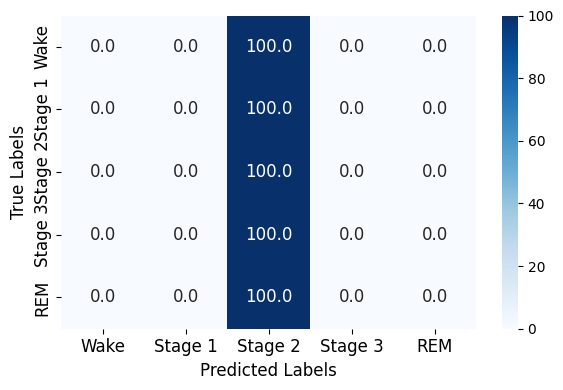

In [85]:
# Step 1: Get predicted labels (argmax on probabilities)
predicted_labels = np.argmax(all_outputs_filtered, axis=1)

fontsize = 12

# Step 2: Compute F1 score for each class
f1_scores = f1_score(all_targets_filtered, predicted_labels, average=None, labels=range(len(class_labels)))
for idx, label in enumerate(class_labels):
    print(f"F1 Score for {label}: {f1_scores[idx]:.3f}")

# Step 3: Create a confusion matrix and normalize it by row to get percentages
conf_matrix = confusion_matrix(all_targets_filtered, predicted_labels, labels=range(len(class_labels)))
conf_matrix_percent = conf_matrix / conf_matrix.sum(axis=1, keepdims=True) * 100

# Plotting the confusion matrix with percentages
plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_matrix_percent,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
    annot_kws={"size": fontsize},  # Font size for numbers inside the heatmap
    cbar_kws={"shrink": 1},  # Adjust colorbar size
)

# Customizing axis labels and ticks
plt.xlabel("Predicted Labels", fontsize=fontsize)
plt.ylabel("True Labels", fontsize=fontsize)
plt.xticks(fontsize=12, ha="center")  # Font size for x-axis tick labels with rotation
plt.yticks(fontsize=12)  # Font size for y-axis tick labels

# Adjust layout and save the figure
plt.tight_layout()
plt.show()


📁 Fichiers disponibles : 3

🎯 MODE OVERFITTING:
   Train: C1_012_PSG1.hdf5
   Val:   HI_050_PSG1.hdf5 (même fichier !)
Epoch 1/100 | Train: Loss=1.3375 Acc=0.497 F1=0.133 | Val: Loss=1.2684 Acc=0.483 F1=0.163
Epoch 2/100 | Train: Loss=1.2998 Acc=0.498 F1=0.135 | Val: Loss=1.3153 Acc=0.483 F1=0.163
Epoch 3/100 | Train: Loss=1.2919 Acc=0.496 F1=0.133 | Val: Loss=1.3192 Acc=0.483 F1=0.163
Epoch 4/100 | Train: Loss=1.2849 Acc=0.497 F1=0.133 | Val: Loss=1.2998 Acc=0.483 F1=0.163
Epoch 5/100 | Train: Loss=1.2752 Acc=0.497 F1=0.133 | Val: Loss=1.2774 Acc=0.483 F1=0.163
Epoch 6/100 | Train: Loss=1.2631 Acc=0.498 F1=0.134 | Val: Loss=1.2622 Acc=0.483 F1=0.163
Epoch 7/100 | Train: Loss=1.2451 Acc=0.499 F1=0.136 | Val: Loss=1.2648 Acc=0.473 F1=0.239
Epoch 8/100 | Train: Loss=1.2059 Acc=0.509 F1=0.153 | Val: Loss=1.3338 Acc=0.277 F1=0.120
Epoch 9/100 | Train: Loss=1.1320 Acc=0.604 F1=0.274 | Val: Loss=1.3797 Acc=0.291 F1=0.141
Epoch 10/100 | Train: Loss=1.0425 Acc=0.625 F1=0.288 | Val: Loss=1.553

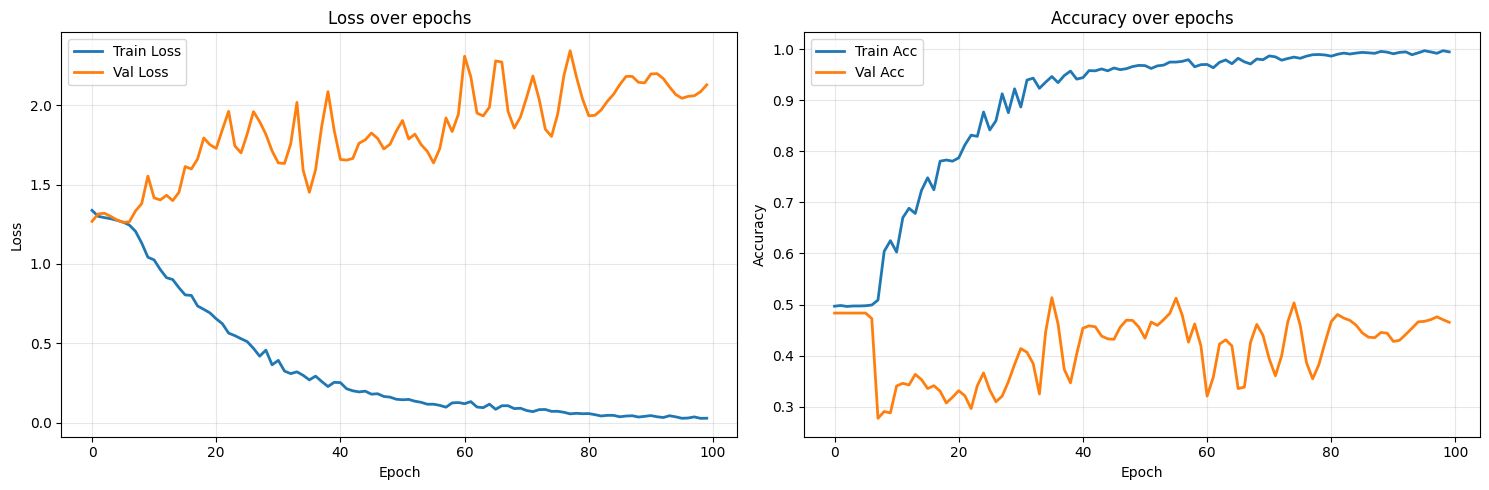


🔍 DIAGNOSTIC:
   ✅ BON ! Le modèle apprend
       → Peut-être besoin de plus d'epochs ou LR plus élevé



In [86]:
base_data_path = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_data\\train_emb"
base_save_path = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\save_training_overfit"


checkpoint_dir = os.path.join(base_save_path, "checkpoints")
log_dir = os.path.join(base_save_path, "logs")
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)

# Trouver tous les fichiers HDF5
hdf5_files = glob(os.path.join(base_data_path, "*.hdf5"))

file_pairs = []
for hdf5_path in hdf5_files:
    hdf5_basename = os.path.basename(hdf5_path).replace('.hdf5', '')
    csv_path = os.path.join(base_data_path, f"{hdf5_basename}.csv")
    
    if os.path.exists(csv_path):
        file_pairs.append((hdf5_path, csv_path))

print(f"\n📁 Fichiers disponibles : {len(file_pairs)}")

if len(file_pairs) >= 2:
    train_pairs = [file_pairs[0]]  # 1 fichier pour train
    val_pairs = [file_pairs[1]]    # LE MÊME pour val (overfit maximum !)
    
    print(f"\n🎯 MODE OVERFITTING:")
    print(f"   Train: {os.path.basename(train_pairs[0][0])}")
    print(f"   Val:   {os.path.basename(val_pairs[0][0])} (même fichier !)")
elif len(file_pairs) == 1:
    train_pairs = [file_pairs[0]]
    val_pairs = [file_pairs[0]]
    print(f"\n🎯 1 seul fichier disponible, utilisé pour train et val")
else:
    raise ValueError("❌ Aucun fichier HDF5-CSV trouvé !")

# Séparer les chemins
train_hdf5 = [pair[0] for pair in train_pairs]
train_labels = [pair[1] for pair in train_pairs]

val_hdf5 = [pair[0] for pair in val_pairs]
val_labels = [pair[1] for pair in val_pairs]

config_overfit = config.copy()
config_overfit['batch_size'] = 1  # Batch size = 1 pour overfit maximum
config_overfit['epochs'] = 100     # 100 epochs
config_overfit['lr'] = 0.001       # Learning rate un peu plus élevé
config_overfit['accumulation_steps'] = 1  # Pas d'accumulation
config_overfit['patience'] = 100   # Pas d'early stopping

# Sauvegarder la config
with open(os.path.join(checkpoint_dir, "config.json"), 'w') as f:
    json.dump(config_overfit, f, indent=4)

train_dataset = SleepEventClassificationDataset(
    config_overfit, 
    CHANNEL_GROUPS_FOR_MODEL, 
    split="train", 
    hdf5_paths=train_hdf5, 
    label_files=train_labels
)

val_dataset = SleepEventClassificationDataset(
    config_overfit, 
    CHANNEL_GROUPS_FOR_MODEL, 
    split="val", 
    hdf5_paths=val_hdf5, 
    label_files=val_labels
)

if len(train_dataset) == 0:
    raise ValueError("❌ Dataset vide !")


train_loader = DataLoader(
    train_dataset,
    batch_size=config_overfit['batch_size'],
    shuffle=False,  # Pas de shuffle pour reproduire exactement
    num_workers=0,  
    collate_fn=sleep_event_finetune_full_collate_fn,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config_overfit['batch_size'],
    shuffle=False,
    num_workers=0,
    collate_fn=sleep_event_finetune_full_collate_fn,
    pin_memory=True if torch.cuda.is_available() else False
)

class MaskedCrossEntropyLoss(nn.Module):
    def __init__(self, class_weights=None):
        super().__init__()
        self.class_weights = class_weights
        self.ce_loss = nn.CrossEntropyLoss(weight=class_weights, reduction='none')
    
    def forward(self, logits, targets, mask):
        B, S, C = logits.shape
        
        logits_flat = logits.reshape(-1, C)
        targets_flat = targets.reshape(-1).long()
        mask_flat = mask.reshape(-1)
        
        loss = self.ce_loss(logits_flat, targets_flat)
        
        if mask_flat.dtype == torch.bool:
            mask_flat = (~mask_flat).float()
        else:
            mask_flat = 1.0 - mask_flat
        
        loss = loss * mask_flat
        
        num_valid = mask_flat.sum()
        if num_valid > 0:
            loss = loss.sum() / num_valid
        else:
            loss = loss.sum()
        
        return loss

criterion = MaskedCrossEntropyLoss(class_weights=None).to(device)

optimizer = optim.AdamW(
    sleep_staging_model.parameters(),
    lr=config_overfit['lr'],
    weight_decay=0  # Pas de régularisation pour overfitting
)


def train_one_epoch_overfit(model, dataloader, criterion, optimizer, device, epoch):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for batch_idx, (x_batch, y_batch, mask_batch, paths) in enumerate(dataloader):
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        mask_batch = mask_batch.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(x_batch, mask_batch)
        
        if isinstance(outputs, tuple):
            if len(outputs) == 3:
                logits, _, mask_temporal = outputs
            else:
                logits, mask_temporal = outputs
        else:
            logits = outputs
            mask_temporal = mask_batch[:, 0, :]
        
        loss = criterion(logits, y_batch, mask_temporal)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        with torch.no_grad():
            preds = torch.argmax(logits, dim=-1)
            
            if mask_temporal.dtype == torch.bool:
                valid_idx = (~mask_temporal).cpu().numpy().flatten()
            else:
                valid_idx = (mask_temporal == 0).cpu().numpy().flatten()
            
            preds_flat = preds.cpu().numpy().flatten()
            labels_flat = y_batch.cpu().numpy().flatten()
            
            all_preds.extend(preds_flat[valid_idx])
            all_labels.extend(labels_flat[valid_idx])
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    
    return avg_loss, accuracy, f1_macro, all_preds, all_labels


def validate_overfit(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for x_batch, y_batch, mask_batch, paths in dataloader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            mask_batch = mask_batch.to(device)
            
            outputs = model(x_batch, mask_batch)
            
            if isinstance(outputs, tuple):
                if len(outputs) == 3:
                    logits, _, mask_temporal = outputs
                else:
                    logits, mask_temporal = outputs
            else:
                logits = outputs
                mask_temporal = mask_batch[:, 0, :]
            
            loss = criterion(logits, y_batch, mask_temporal)
            total_loss += loss.item()
            
            preds = torch.argmax(logits, dim=-1)
            
            if mask_temporal.dtype == torch.bool:
                valid_idx = (~mask_temporal).cpu().numpy().flatten()
            else:
                valid_idx = (mask_temporal == 0).cpu().numpy().flatten()
            
            preds_flat = preds.cpu().numpy().flatten()
            labels_flat = y_batch.cpu().numpy().flatten()
            
            all_preds.extend(preds_flat[valid_idx])
            all_labels.extend(labels_flat[valid_idx])
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    
    return avg_loss, accuracy, f1_macro, all_preds, all_labels


history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'val_loss': [], 'val_acc': [], 'val_f1': []
}

best_val_f1 = 0.0

for epoch in range(config_overfit['epochs']):
    print(f"Epoch {epoch+1}/{config_overfit['epochs']}", end=" | ")
    
    # Train
    train_loss, train_acc, train_f1, train_preds, train_labels = train_one_epoch_overfit(
        sleep_staging_model, train_loader, criterion, optimizer, device, epoch
    )
    
    # Validate
    val_loss, val_acc, val_f1, val_preds, val_labels = validate_overfit(
        sleep_staging_model, val_loader, criterion, device
    )
    
    # History
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    # Print concis
    print(f"Train: Loss={train_loss:.4f} Acc={train_acc:.3f} F1={train_f1:.3f} | "
          f"Val: Loss={val_loss:.4f} Acc={val_acc:.3f} F1={val_f1:.3f}")
    
    # Sauvegarder le meilleur
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': sleep_staging_model.module.state_dict() if isinstance(sleep_staging_model, nn.DataParallel) else sleep_staging_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1_macro': val_f1,
            'history': history
        }
        
        torch.save(checkpoint, os.path.join(checkpoint_dir, 'best_overfit.pth'))
    
    # Affichage détaillé tous les 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"\n📊 Epoch {epoch+1} - Rapport détaillé:")
        print(f"Labels: {len(val_labels)} dimensions")
        print(f"Prédictions: {len(val_preds)} dimensions")
        print(len(val_labels), len(val_preds))
        print(classification_report(
            val_labels, val_preds,
            labels=[0, 1, 2, 3, 4],
            target_names=['Wake', 'REM', 'N1', 'N2', 'N3'],
            digits=3,
            zero_division=0
        ))
        print()


print(f"\n{'='*60}")
print(f"✅ ENTRAÎNEMENT TERMINÉ")
print(f"{'='*60}")

print(f"\n📈 Meilleur résultat:")
print(f"   Val F1-Macro: {best_val_f1:.4f}")

print(f"\n📊 Progression:")
print(f"   Epoch   1: Train Acc={history['train_acc'][0]:.3f}, Val Acc={history['val_acc'][0]:.3f}")
print(f"   Epoch  50: Train Acc={history['train_acc'][49]:.3f}, Val Acc={history['val_acc'][49]:.3f}") if len(history['train_acc']) >= 50 else None
print(f"   Epoch 100: Train Acc={history['train_acc'][-1]:.3f}, Val Acc={history['val_acc'][-1]:.3f}")
    
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss
ax1.plot(history['train_loss'], label='Train Loss', linewidth=2)
ax1.plot(history['val_loss'], label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss over epochs')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(history['train_acc'], label='Train Acc', linewidth=2)
ax2.plot(history['val_acc'], label='Val Acc', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy over epochs')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(log_dir, 'overfit_curves.png'), dpi=150)
print(f"\n✅ Graphiques sauvegardés: {os.path.join(log_dir, 'overfit_curves.png')}")
plt.show()

# ============================================================
# DIAGNOSTIC
# ============================================================

print(f"\n🔍 DIAGNOSTIC:")

final_train_acc = history['train_acc'][-1]
final_val_acc = history['val_acc'][-1]

if final_train_acc > 0.95 and final_val_acc > 0.95:
    print(f"   ✅✅✅ EXCELLENT ! Le modèle peut overfitter")
    print(f"       → Le modèle FONCTIONNE et peut apprendre")
    print(f"       → Le problème vient de l'alignement ou du dataset complet")
elif final_train_acc > 0.70:
    print(f"   ✅ BON ! Le modèle apprend")
    print(f"       → Peut-être besoin de plus d'epochs ou LR plus élevé")
elif final_train_acc > 0.40:
    print(f"   ⚠️ MOYEN. Le modèle apprend lentement")
    print(f"       → Vérifier le format d'entrée ou l'architecture")
else:
    print(f"   ❌ PROBLÈME ! Le modèle n'apprend pas")
    print(f"       → Format d'entrée incorrect")
    print(f"       → Poids frozen")
    print(f"       → Bug dans le forward pass")

print(f"\n{'='*60}")


🔍 DIAGNOSTIC:
   ✅ BON ! Le modèle apprend
       → Peut-être besoin de plus d'epochs ou LR plus élevé

📊 MATRICE DE CONFUSION FINALE

📊 Matrice de confusion (nombres absolus):
           Prédit →
   Vrai ↓    Wake     REM      N1      N2      N3
   Wake      211       0      74     135       0
   REM        59       0      21      40       0
   N1        270       0     503     271       0
   N2        149       0     136     291       0
   N3          0       0       0       0       0

📊 Matrice de confusion (pourcentages par ligne):
           Prédit →
   Vrai ↓    Wake     REM      N1      N2      N3
   Wake    50.2%    0.0%   17.6%   32.1%    0.0%
   REM     49.2%    0.0%   17.5%   33.3%    0.0%
   N1      25.9%    0.0%   48.2%   26.0%    0.0%
   N2      25.9%    0.0%   23.6%   50.5%    0.0%
   N3       nan%    nan%    nan%    nan%    nan%


C:\Users\gabri\AppData\Local\Temp\ipykernel_11036\2889883098.py:80: RuntimeWarning: invalid value encountered in divide
  cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100



✅ Matrice de confusion sauvegardée: C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\save_training_overfit\logs\confusion_matrix_final.png


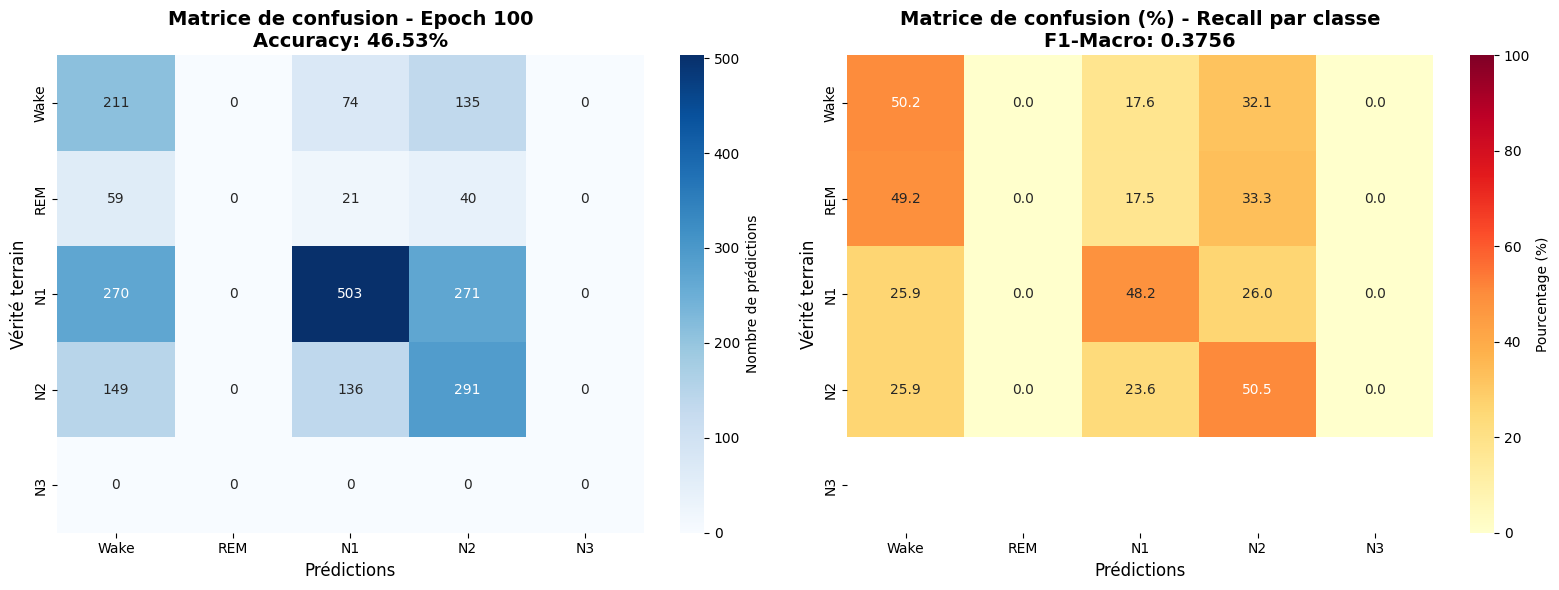


📈 MÉTRIQUES PAR CLASSE

Classe    Support  Precision     Recall   F1-Score
--------------------------------------------------
Wake          420      0.306      0.502      0.381
REM           120      0.000      0.000      0.000
N1           1044      0.685      0.482      0.566
N2            576      0.395      0.505      0.443
N3              0      0.000      0.000      0.000

Macro avg               0.277      0.298      0.278

📊 Distribution des classes (validation):
   Wake:   420 ( 19.4%) █████████
   REM :   120 (  5.6%) ██
   N1  :  1044 ( 48.3%) ████████████████████████
   N2  :   576 ( 26.7%) █████████████
   N3  :     0 (  0.0%) 

🔍 ANALYSE DES ERREURS PRINCIPALES

🔝 Top 5 des confusions:
     271 × N1   → N2   ( 26.0% des N1)
     270 × N1   → Wake ( 25.9% des N1)
     149 × N2   → Wake ( 25.9% des N2)
     136 × N2   → N1   ( 23.6% des N2)
     135 × Wake → N2   ( 32.1% des Wake)

✅ Historique sauvegardé: C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical

In [87]:
# ============================================================
# DIAGNOSTIC FINAL AVEC MATRICE DE CONFUSION
# ============================================================

print(f"\n🔍 DIAGNOSTIC:")

final_train_acc = history['train_acc'][-1]
final_val_acc = history['val_acc'][-1]

if final_train_acc > 0.95 and final_val_acc > 0.95:
    print(f"   ✅✅✅ EXCELLENT ! Le modèle peut overfitter")
    print(f"       → Le modèle FONCTIONNE et peut apprendre")
    print(f"       → Le problème vient de l'alignement ou du dataset complet")
elif final_train_acc > 0.70:
    print(f"   ✅ BON ! Le modèle apprend")
    print(f"       → Peut-être besoin de plus d'epochs ou LR plus élevé")
elif final_train_acc > 0.40:
    print(f"   ⚠️ MOYEN. Le modèle apprend lentement")
    print(f"       → Vérifier le format d'entrée ou l'architecture")
else:
    print(f"   ❌ PROBLÈME ! Le modèle n'apprend pas")
    print(f"       → Format d'entrée incorrect")
    print(f"       → Poids frozen")
    print(f"       → Bug dans le forward pass")

# ============================================================
# MATRICE DE CONFUSION FINALE
# ============================================================

print(f"\n{'='*60}")
print(f"📊 MATRICE DE CONFUSION FINALE")
print(f"{'='*60}")

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Obtenir les prédictions finales sur val
model = sleep_staging_model
model.eval()

final_preds = []
final_labels = []

with torch.no_grad():
    for x_batch, y_batch, mask_batch, paths in val_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        mask_batch = mask_batch.to(device)
        
        outputs = model(x_batch, mask_batch)
        
        if isinstance(outputs, tuple):
            if len(outputs) == 3:
                logits, _, mask_temporal = outputs
            else:
                logits, mask_temporal = outputs
        else:
            logits = outputs
            mask_temporal = mask_batch[:, 0, :]
        
        preds = torch.argmax(logits, dim=-1)
        
        if mask_temporal.dtype == torch.bool:
            valid_idx = (~mask_temporal).cpu().numpy().flatten()
        else:
            valid_idx = (mask_temporal == 0).cpu().numpy().flatten()
        
        preds_flat = preds.cpu().numpy().flatten()
        labels_flat = y_batch.cpu().numpy().flatten()
        
        final_preds.extend(preds_flat[valid_idx])
        final_labels.extend(labels_flat[valid_idx])

# Calculer la matrice de confusion
cm = confusion_matrix(final_labels, final_preds, labels=[0, 1, 2, 3, 4])

# Calculer les pourcentages (normalisation par ligne)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Noms des classes
stage_names = ['Wake', 'REM', 'N1', 'N2', 'N3']

# ============================================================
# AFFICHAGE TEXTUEL
# ============================================================

print(f"\n📊 Matrice de confusion (nombres absolus):")
print(f"           Prédit →")
print(f"   Vrai ↓  {'  '.join([f'{name:>6s}' for name in stage_names])}")
for i, name in enumerate(stage_names):
    row_str = '  '.join([f'{val:6d}' for val in cm[i]])
    print(f"   {name:4s}   {row_str}")

print(f"\n📊 Matrice de confusion (pourcentages par ligne):")
print(f"           Prédit →")
print(f"   Vrai ↓  {'  '.join([f'{name:>6s}' for name in stage_names])}")
for i, name in enumerate(stage_names):
    row_str = '  '.join([f'{val:5.1f}%' for val in cm_percent[i]])
    print(f"   {name:4s}   {row_str}")

# ============================================================
# VISUALISATION GRAPHIQUE
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Matrice 1 : Nombres absolus
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=stage_names, yticklabels=stage_names,
            cbar_kws={'label': 'Nombre de prédictions'},
            ax=ax1)
ax1.set_xlabel('Prédictions', fontsize=12)
ax1.set_ylabel('Vérité terrain', fontsize=12)
ax1.set_title(f'Matrice de confusion - Epoch {config_overfit["epochs"]}\nAccuracy: {final_val_acc:.2%}', 
              fontsize=14, fontweight='bold')

# Matrice 2 : Pourcentages
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='YlOrRd', 
            xticklabels=stage_names, yticklabels=stage_names,
            cbar_kws={'label': 'Pourcentage (%)'},
            vmin=0, vmax=100,
            ax=ax2)
ax2.set_xlabel('Prédictions', fontsize=12)
ax2.set_ylabel('Vérité terrain', fontsize=12)
ax2.set_title(f'Matrice de confusion (%) - Recall par classe\nF1-Macro: {best_val_f1:.4f}', 
              fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(log_dir, 'confusion_matrix_final.png'), dpi=150, bbox_inches='tight')
print(f"\n✅ Matrice de confusion sauvegardée: {os.path.join(log_dir, 'confusion_matrix_final.png')}")
plt.show()

# ============================================================
# MÉTRIQUES PAR CLASSE
# ============================================================

print(f"\n{'='*60}")
print(f"📈 MÉTRIQUES PAR CLASSE")
print(f"{'='*60}")

from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    final_labels, final_preds, 
    labels=[0, 1, 2, 3, 4],
    zero_division=0
)

print(f"\n{'Classe':<8s} {'Support':>8s} {'Precision':>10s} {'Recall':>10s} {'F1-Score':>10s}")
print(f"{'-'*50}")

for i, name in enumerate(stage_names):
    print(f"{name:<8s} {support[i]:>8d} {precision[i]:>10.3f} {recall[i]:>10.3f} {f1[i]:>10.3f}")

print(f"\n{'Macro avg':<8s} {'':<8s} {precision.mean():>10.3f} {recall.mean():>10.3f} {f1.mean():>10.3f}")

# Distribution des classes
print(f"\n📊 Distribution des classes (validation):")
for i, name in enumerate(stage_names):
    pct = support[i] / sum(support) * 100
    bar = "█" * int(pct / 2)
    print(f"   {name:4s}: {support[i]:5d} ({pct:5.1f}%) {bar}")

# ============================================================
# ANALYSE DES ERREURS
# ============================================================

print(f"\n{'='*60}")
print(f"🔍 ANALYSE DES ERREURS PRINCIPALES")
print(f"{'='*60}")

# Trouver les confusions les plus fréquentes (hors diagonale)
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

# Top 5 confusions
top_confusions = []
for i in range(5):
    for j in range(5):
        if i != j and cm[i, j] > 0:
            top_confusions.append((cm[i, j], stage_names[i], stage_names[j]))

top_confusions.sort(reverse=True)

print(f"\n🔝 Top 5 des confusions:")
for count, true_class, pred_class in top_confusions[:5]:
    pct = count / cm[stage_names.index(true_class)].sum() * 100
    print(f"   {count:5d} × {true_class:4s} → {pred_class:4s} ({pct:5.1f}% des {true_class})")

print(f"\n{'='*60}")

# ============================================================
# SAUVEGARDER L'HISTORIQUE
# ============================================================

import pandas as pd

history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(log_dir, 'history.csv'), index=False)
print(f"✅ Historique sauvegardé: {os.path.join(log_dir, 'history.csv')}")

print(f"\n{'='*60}")

faire model pretrain + finetuning vs model hasardeux + finetuning


📁 Fichiers disponibles : 3

🎯 MODE OVERFITTING:
   Train: C1_012_PSG1.hdf5
   Val:   C1_012_PSG1.hdf5 (même fichier !)
Epoch 1/100 | Train: Loss=3.1655 Acc=0.092 F1=0.060 | Val: Loss=2.0082 Acc=0.508 F1=0.157
Epoch 2/100 | Train: Loss=1.8666 Acc=0.526 F1=0.192 | Val: Loss=3.1271 Acc=0.250 F1=0.080
Epoch 3/100 | Train: Loss=3.1339 Acc=0.250 F1=0.080 | Val: Loss=1.8519 Acc=0.266 F1=0.094
Epoch 4/100 | Train: Loss=1.9518 Acc=0.306 F1=0.127 | Val: Loss=1.5660 Acc=0.497 F1=0.133
Epoch 5/100 | Train: Loss=1.5639 Acc=0.519 F1=0.183 | Val: Loss=1.7402 Acc=0.497 F1=0.133
Epoch 6/100 | Train: Loss=1.7020 Acc=0.498 F1=0.135 | Val: Loss=1.7293 Acc=0.497 F1=0.133
Epoch 7/100 | Train: Loss=1.7124 Acc=0.497 F1=0.133 | Val: Loss=1.6212 Acc=0.497 F1=0.133
Epoch 8/100 | Train: Loss=1.6018 Acc=0.498 F1=0.135 | Val: Loss=1.4956 Acc=0.497 F1=0.133
Epoch 9/100 | Train: Loss=1.4925 Acc=0.497 F1=0.140 | Val: Loss=1.4039 Acc=0.497 F1=0.133
Epoch 10/100 | Train: Loss=1.4212 Acc=0.503 F1=0.177 | Val: Loss=1.363

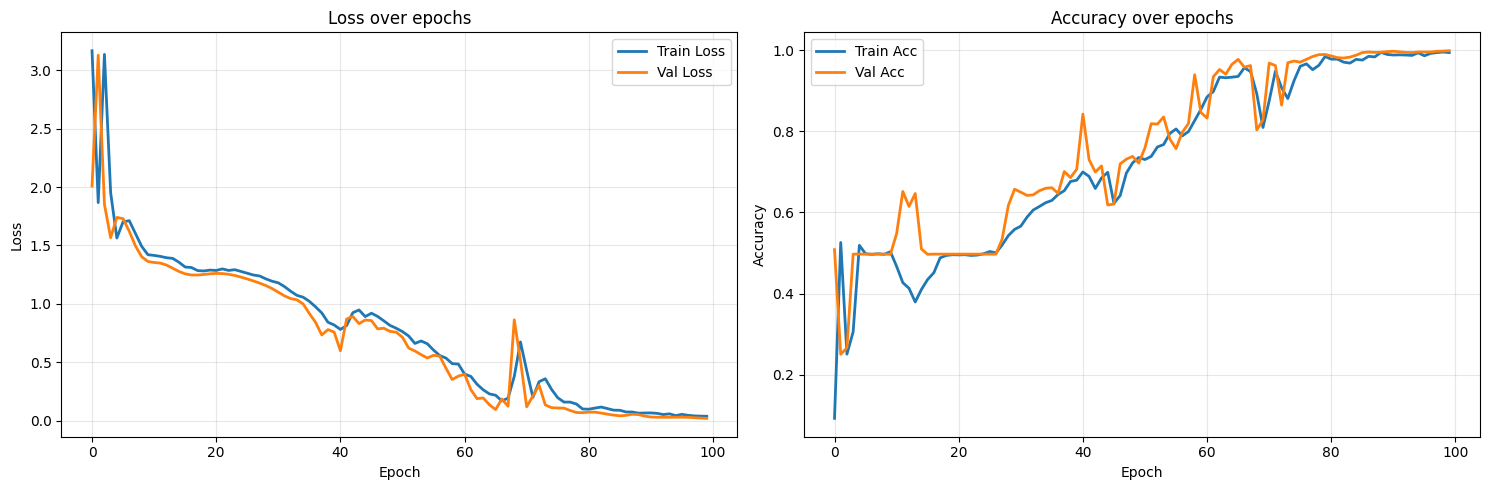


🔍 DIAGNOSTIC:
   ✅✅✅ EXCELLENT ! Le modèle peut overfitter
       → Le modèle FONCTIONNE et peut apprendre
       → Le problème vient de l'alignement ou du dataset complet



In [88]:
base_data_path = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_data\\train_emb_hazard"
base_save_path = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\save_training_overfit_hasard"


checkpoint_dir = os.path.join(base_save_path, "checkpoints")
log_dir = os.path.join(base_save_path, "logs")
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)

# Trouver tous les fichiers HDF5
hdf5_files = glob(os.path.join(base_data_path, "*.hdf5"))

file_pairs = []
for hdf5_path in hdf5_files:
    hdf5_basename = os.path.basename(hdf5_path).replace('.hdf5', '')
    csv_path = os.path.join(base_data_path, f"{hdf5_basename}.csv")
    
    if os.path.exists(csv_path):
        file_pairs.append((hdf5_path, csv_path))

print(f"\n📁 Fichiers disponibles : {len(file_pairs)}")

if len(file_pairs) >= 2:
    train_pairs = [file_pairs[0]]  # 1 fichier pour train
    val_pairs = [file_pairs[0]]    # LE MÊME pour val (overfit maximum !)
    
    print(f"\n🎯 MODE OVERFITTING:")
    print(f"   Train: {os.path.basename(train_pairs[0][0])}")
    print(f"   Val:   {os.path.basename(val_pairs[0][0])} (même fichier !)")
elif len(file_pairs) == 1:
    train_pairs = [file_pairs[0]]
    val_pairs = [file_pairs[0]]
    print(f"\n🎯 1 seul fichier disponible, utilisé pour train et val")
else:
    raise ValueError("❌ Aucun fichier HDF5-CSV trouvé !")

# Séparer les chemins
train_hdf5 = [pair[0] for pair in train_pairs]
train_labels = [pair[1] for pair in train_pairs]

val_hdf5 = [pair[0] for pair in val_pairs]
val_labels = [pair[1] for pair in val_pairs]

config_overfit = config.copy()
config_overfit['batch_size'] = 1  # Batch size = 1 pour overfit maximum
config_overfit['epochs'] = 100     # 100 epochs
config_overfit['lr'] = 0.001       # Learning rate un peu plus élevé
config_overfit['accumulation_steps'] = 1  # Pas d'accumulation
config_overfit['patience'] = 100   # Pas d'early stopping

# Sauvegarder la config
with open(os.path.join(checkpoint_dir, "config.json"), 'w') as f:
    json.dump(config_overfit, f, indent=4)

train_dataset = SleepEventClassificationDataset(
    config_overfit, 
    CHANNEL_GROUPS_FOR_MODEL, 
    split="train", 
    hdf5_paths=train_hdf5, 
    label_files=train_labels
)

val_dataset = SleepEventClassificationDataset(
    config_overfit, 
    CHANNEL_GROUPS_FOR_MODEL, 
    split="val", 
    hdf5_paths=val_hdf5, 
    label_files=val_labels
)

if len(train_dataset) == 0:
    raise ValueError("❌ Dataset vide !")


train_loader = DataLoader(
    train_dataset,
    batch_size=config_overfit['batch_size'],
    shuffle=False,  # Pas de shuffle pour reproduire exactement
    num_workers=0,  
    collate_fn=sleep_event_finetune_full_collate_fn,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config_overfit['batch_size'],
    shuffle=False,
    num_workers=0,
    collate_fn=sleep_event_finetune_full_collate_fn,
    pin_memory=True if torch.cuda.is_available() else False
)

class MaskedCrossEntropyLoss(nn.Module):
    def __init__(self, class_weights=None):
        super().__init__()
        self.class_weights = class_weights
        self.ce_loss = nn.CrossEntropyLoss(weight=class_weights, reduction='none')
    
    def forward(self, logits, targets, mask):
        B, S, C = logits.shape
        
        logits_flat = logits.reshape(-1, C)
        targets_flat = targets.reshape(-1).long()
        mask_flat = mask.reshape(-1)
        
        loss = self.ce_loss(logits_flat, targets_flat)
        
        if mask_flat.dtype == torch.bool:
            mask_flat = (~mask_flat).float()
        else:
            mask_flat = 1.0 - mask_flat
        
        loss = loss * mask_flat
        
        num_valid = mask_flat.sum()
        if num_valid > 0:
            loss = loss.sum() / num_valid
        else:
            loss = loss.sum()
        
        return loss

criterion = MaskedCrossEntropyLoss(class_weights=None).to(device)

optimizer = optim.AdamW(
    sleep_staging_model.parameters(),
    lr=config_overfit['lr'],
    weight_decay=0  # Pas de régularisation pour overfitting
)


def train_one_epoch_overfit(model, dataloader, criterion, optimizer, device, epoch):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for batch_idx, (x_batch, y_batch, mask_batch, paths) in enumerate(dataloader):
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        mask_batch = mask_batch.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(x_batch, mask_batch)
        
        if isinstance(outputs, tuple):
            if len(outputs) == 3:
                logits, _, mask_temporal = outputs
            else:
                logits, mask_temporal = outputs
        else:
            logits = outputs
            mask_temporal = mask_batch[:, 0, :]
        
        loss = criterion(logits, y_batch, mask_temporal)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        with torch.no_grad():
            preds = torch.argmax(logits, dim=-1)
            
            if mask_temporal.dtype == torch.bool:
                valid_idx = (~mask_temporal).cpu().numpy().flatten()
            else:
                valid_idx = (mask_temporal == 0).cpu().numpy().flatten()
            
            preds_flat = preds.cpu().numpy().flatten()
            labels_flat = y_batch.cpu().numpy().flatten()
            
            all_preds.extend(preds_flat[valid_idx])
            all_labels.extend(labels_flat[valid_idx])
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    
    return avg_loss, accuracy, f1_macro, all_preds, all_labels


def validate_overfit(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for x_batch, y_batch, mask_batch, paths in dataloader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            mask_batch = mask_batch.to(device)
            
            outputs = model(x_batch, mask_batch)
            
            if isinstance(outputs, tuple):
                if len(outputs) == 3:
                    logits, _, mask_temporal = outputs
                else:
                    logits, mask_temporal = outputs
            else:
                logits = outputs
                mask_temporal = mask_batch[:, 0, :]
            
            loss = criterion(logits, y_batch, mask_temporal)
            total_loss += loss.item()
            
            preds = torch.argmax(logits, dim=-1)
            
            if mask_temporal.dtype == torch.bool:
                valid_idx = (~mask_temporal).cpu().numpy().flatten()
            else:
                valid_idx = (mask_temporal == 0).cpu().numpy().flatten()
            
            preds_flat = preds.cpu().numpy().flatten()
            labels_flat = y_batch.cpu().numpy().flatten()
            
            all_preds.extend(preds_flat[valid_idx])
            all_labels.extend(labels_flat[valid_idx])
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    
    return avg_loss, accuracy, f1_macro, all_preds, all_labels


history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'val_loss': [], 'val_acc': [], 'val_f1': []
}

best_val_f1 = 0.0

for epoch in range(config_overfit['epochs']):
    print(f"Epoch {epoch+1}/{config_overfit['epochs']}", end=" | ")
    
    # Train
    train_loss, train_acc, train_f1, train_preds, train_labels = train_one_epoch_overfit(
        sleep_staging_model, train_loader, criterion, optimizer, device, epoch
    )
    
    # Validate
    val_loss, val_acc, val_f1, val_preds, val_labels = validate_overfit(
        sleep_staging_model, val_loader, criterion, device
    )
    
    # History
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    # Print concis
    print(f"Train: Loss={train_loss:.4f} Acc={train_acc:.3f} F1={train_f1:.3f} | "
          f"Val: Loss={val_loss:.4f} Acc={val_acc:.3f} F1={val_f1:.3f}")
    
    # Sauvegarder le meilleur
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': sleep_staging_model.module.state_dict() if isinstance(sleep_staging_model, nn.DataParallel) else sleep_staging_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1_macro': val_f1,
            'history': history
        }
        
        torch.save(checkpoint, os.path.join(checkpoint_dir, 'best_overfit.pth'))
    
    # Affichage détaillé tous les 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"\n📊 Epoch {epoch+1} - Rapport détaillé:")
        print(classification_report(
            val_labels, val_preds,
            labels=[0, 1, 2, 3, 4],
            target_names=['Wake', 'REM', 'N1', 'N2', 'N3'],
            digits=3,
            zero_division=0
        ))
        print()


print(f"\n{'='*60}")
print(f"✅ ENTRAÎNEMENT TERMINÉ")
print(f"{'='*60}")

print(f"\n📈 Meilleur résultat:")
print(f"   Val F1-Macro: {best_val_f1:.4f}")

print(f"\n📊 Progression:")
print(f"   Epoch   1: Train Acc={history['train_acc'][0]:.3f}, Val Acc={history['val_acc'][0]:.3f}")
print(f"   Epoch  50: Train Acc={history['train_acc'][49]:.3f}, Val Acc={history['val_acc'][49]:.3f}") if len(history['train_acc']) >= 50 else None
print(f"   Epoch 100: Train Acc={history['train_acc'][-1]:.3f}, Val Acc={history['val_acc'][-1]:.3f}")
    
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss
ax1.plot(history['train_loss'], label='Train Loss', linewidth=2)
ax1.plot(history['val_loss'], label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss over epochs')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(history['train_acc'], label='Train Acc', linewidth=2)
ax2.plot(history['val_acc'], label='Val Acc', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy over epochs')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(log_dir, 'overfit_curves.png'), dpi=150)
print(f"\n✅ Graphiques sauvegardés: {os.path.join(log_dir, 'overfit_curves.png')}")
plt.show()

# ============================================================
# DIAGNOSTIC
# ============================================================

print(f"\n🔍 DIAGNOSTIC:")

final_train_acc = history['train_acc'][-1]
final_val_acc = history['val_acc'][-1]

if final_train_acc > 0.95 and final_val_acc > 0.95:
    print(f"   ✅✅✅ EXCELLENT ! Le modèle peut overfitter")
    print(f"       → Le modèle FONCTIONNE et peut apprendre")
    print(f"       → Le problème vient de l'alignement ou du dataset complet")
elif final_train_acc > 0.70:
    print(f"   ✅ BON ! Le modèle apprend")
    print(f"       → Peut-être besoin de plus d'epochs ou LR plus élevé")
elif final_train_acc > 0.40:
    print(f"   ⚠️ MOYEN. Le modèle apprend lentement")
    print(f"       → Vérifier le format d'entrée ou l'architecture")
else:
    print(f"   ❌ PROBLÈME ! Le modèle n'apprend pas")
    print(f"       → Format d'entrée incorrect")
    print(f"       → Poids frozen")
    print(f"       → Bug dans le forward pass")

print(f"\n{'='*60}")


🔍 DIAGNOSTIC:
   ✅✅✅ EXCELLENT ! Le modèle peut overfitter
       → Le modèle FONCTIONNE et peut apprendre
       → Le problème vient de l'alignement ou du dataset complet

📊 MATRICE DE CONFUSION FINALE

📊 Matrice de confusion (nombres absolus):
           Prédit →
   Vrai ↓    Wake     REM      N1      N2      N3
   Wake      293       1       0       0       0
   REM         0      60       0       0       0
   N1          0       0    1074       0       0
   N2          1       0       0     539       0
   N3          0       0       0       0     192

📊 Matrice de confusion (pourcentages par ligne):
           Prédit →
   Vrai ↓    Wake     REM      N1      N2      N3
   Wake    99.7%    0.3%    0.0%    0.0%    0.0%
   REM      0.0%  100.0%    0.0%    0.0%    0.0%
   N1       0.0%    0.0%  100.0%    0.0%    0.0%
   N2       0.2%    0.0%    0.0%   99.8%    0.0%
   N3       0.0%    0.0%    0.0%    0.0%  100.0%

✅ Matrice de confusion sauvegardée: C:\Users\gabri\Desktop\stage_sommeil

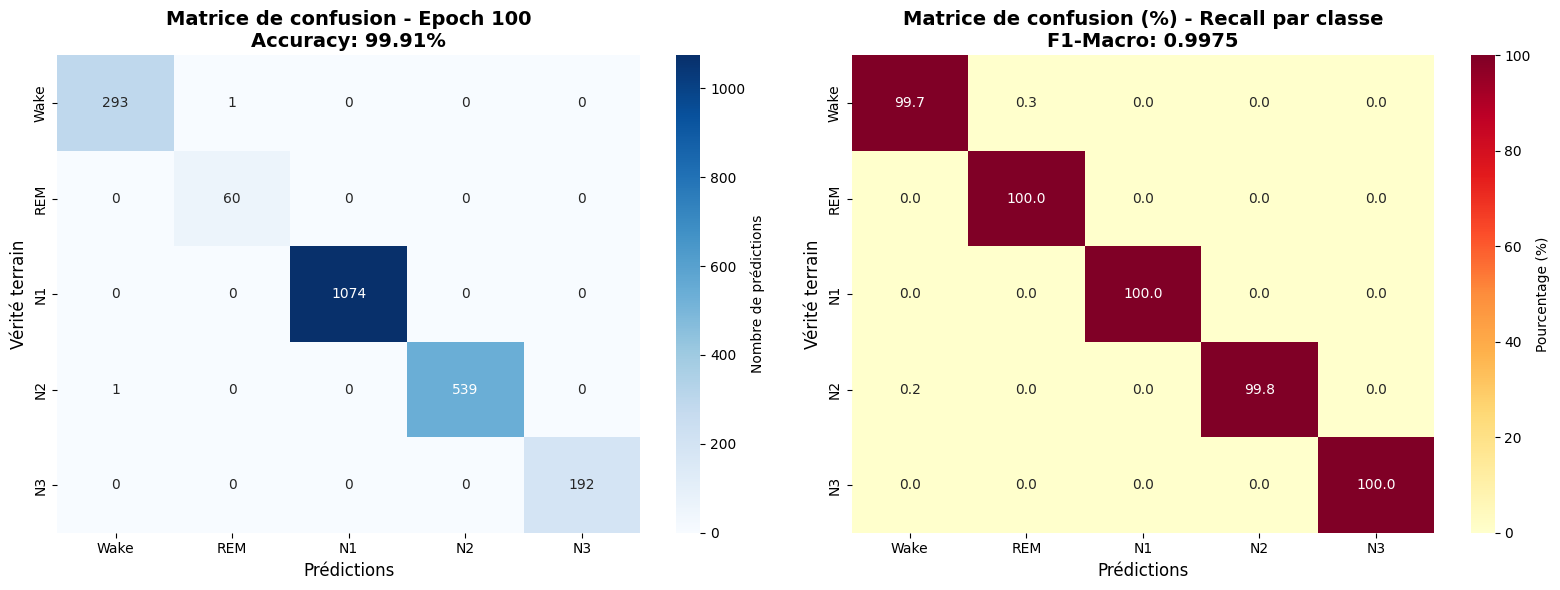


📈 MÉTRIQUES PAR CLASSE

Classe    Support  Precision     Recall   F1-Score
--------------------------------------------------
Wake          294      0.997      0.997      0.997
REM            60      0.984      1.000      0.992
N1           1074      1.000      1.000      1.000
N2            540      1.000      0.998      0.999
N3            192      1.000      1.000      1.000

Macro avg               0.996      0.999      0.997

📊 Distribution des classes (validation):
   Wake:   294 ( 13.6%) ██████
   REM :    60 (  2.8%) █
   N1  :  1074 ( 49.7%) ████████████████████████
   N2  :   540 ( 25.0%) ████████████
   N3  :   192 (  8.9%) ████

🔍 ANALYSE DES ERREURS PRINCIPALES

🔝 Top 5 des confusions:
       1 × Wake → REM  (  0.3% des Wake)
       1 × N2   → Wake (  0.2% des N2)

✅ Historique sauvegardé: C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\save_training_overfit_hasard\logs\history.csv



In [89]:
# ============================================================
# DIAGNOSTIC FINAL AVEC MATRICE DE CONFUSION
# ============================================================

print(f"\n🔍 DIAGNOSTIC:")

final_train_acc = history['train_acc'][-1]
final_val_acc = history['val_acc'][-1]

if final_train_acc > 0.95 and final_val_acc > 0.95:
    print(f"   ✅✅✅ EXCELLENT ! Le modèle peut overfitter")
    print(f"       → Le modèle FONCTIONNE et peut apprendre")
    print(f"       → Le problème vient de l'alignement ou du dataset complet")
elif final_train_acc > 0.70:
    print(f"   ✅ BON ! Le modèle apprend")
    print(f"       → Peut-être besoin de plus d'epochs ou LR plus élevé")
elif final_train_acc > 0.40:
    print(f"   ⚠️ MOYEN. Le modèle apprend lentement")
    print(f"       → Vérifier le format d'entrée ou l'architecture")
else:
    print(f"   ❌ PROBLÈME ! Le modèle n'apprend pas")
    print(f"       → Format d'entrée incorrect")
    print(f"       → Poids frozen")
    print(f"       → Bug dans le forward pass")

# ============================================================
# MATRICE DE CONFUSION FINALE
# ============================================================

print(f"\n{'='*60}")
print(f"📊 MATRICE DE CONFUSION FINALE")
print(f"{'='*60}")

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Obtenir les prédictions finales sur val
model = sleep_staging_model
model.eval()

final_preds = []
final_labels = []

with torch.no_grad():
    for x_batch, y_batch, mask_batch, paths in val_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        mask_batch = mask_batch.to(device)
        
        outputs = model(x_batch, mask_batch)
        
        if isinstance(outputs, tuple):
            if len(outputs) == 3:
                logits, _, mask_temporal = outputs
            else:
                logits, mask_temporal = outputs
        else:
            logits = outputs
            mask_temporal = mask_batch[:, 0, :]
        
        preds = torch.argmax(logits, dim=-1)
        
        if mask_temporal.dtype == torch.bool:
            valid_idx = (~mask_temporal).cpu().numpy().flatten()
        else:
            valid_idx = (mask_temporal == 0).cpu().numpy().flatten()
        
        preds_flat = preds.cpu().numpy().flatten()
        labels_flat = y_batch.cpu().numpy().flatten()
        
        final_preds.extend(preds_flat[valid_idx])
        final_labels.extend(labels_flat[valid_idx])

# Calculer la matrice de confusion
cm = confusion_matrix(final_labels, final_preds, labels=[0, 1, 2, 3, 4])

# Calculer les pourcentages (normalisation par ligne)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Noms des classes
stage_names = ['Wake', 'REM', 'N1', 'N2', 'N3']

# ============================================================
# AFFICHAGE TEXTUEL
# ============================================================

print(f"\n📊 Matrice de confusion (nombres absolus):")
print(f"           Prédit →")
print(f"   Vrai ↓  {'  '.join([f'{name:>6s}' for name in stage_names])}")
for i, name in enumerate(stage_names):
    row_str = '  '.join([f'{val:6d}' for val in cm[i]])
    print(f"   {name:4s}   {row_str}")

print(f"\n📊 Matrice de confusion (pourcentages par ligne):")
print(f"           Prédit →")
print(f"   Vrai ↓  {'  '.join([f'{name:>6s}' for name in stage_names])}")
for i, name in enumerate(stage_names):
    row_str = '  '.join([f'{val:5.1f}%' for val in cm_percent[i]])
    print(f"   {name:4s}   {row_str}")

# ============================================================
# VISUALISATION GRAPHIQUE
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Matrice 1 : Nombres absolus
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=stage_names, yticklabels=stage_names,
            cbar_kws={'label': 'Nombre de prédictions'},
            ax=ax1)
ax1.set_xlabel('Prédictions', fontsize=12)
ax1.set_ylabel('Vérité terrain', fontsize=12)
ax1.set_title(f'Matrice de confusion - Epoch {config_overfit["epochs"]}\nAccuracy: {final_val_acc:.2%}', 
              fontsize=14, fontweight='bold')

# Matrice 2 : Pourcentages
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='YlOrRd', 
            xticklabels=stage_names, yticklabels=stage_names,
            cbar_kws={'label': 'Pourcentage (%)'},
            vmin=0, vmax=100,
            ax=ax2)
ax2.set_xlabel('Prédictions', fontsize=12)
ax2.set_ylabel('Vérité terrain', fontsize=12)
ax2.set_title(f'Matrice de confusion (%) - Recall par classe\nF1-Macro: {best_val_f1:.4f}', 
              fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(log_dir, 'confusion_matrix_final.png'), dpi=150, bbox_inches='tight')
print(f"\n✅ Matrice de confusion sauvegardée: {os.path.join(log_dir, 'confusion_matrix_final.png')}")
plt.show()

# ============================================================
# MÉTRIQUES PAR CLASSE
# ============================================================

print(f"\n{'='*60}")
print(f"📈 MÉTRIQUES PAR CLASSE")
print(f"{'='*60}")

from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    final_labels, final_preds, 
    labels=[0, 1, 2, 3, 4],
    zero_division=0
)

print(f"\n{'Classe':<8s} {'Support':>8s} {'Precision':>10s} {'Recall':>10s} {'F1-Score':>10s}")
print(f"{'-'*50}")

for i, name in enumerate(stage_names):
    print(f"{name:<8s} {support[i]:>8d} {precision[i]:>10.3f} {recall[i]:>10.3f} {f1[i]:>10.3f}")

print(f"\n{'Macro avg':<8s} {'':<8s} {precision.mean():>10.3f} {recall.mean():>10.3f} {f1.mean():>10.3f}")

# Distribution des classes
print(f"\n📊 Distribution des classes (validation):")
for i, name in enumerate(stage_names):
    pct = support[i] / sum(support) * 100
    bar = "█" * int(pct / 2)
    print(f"   {name:4s}: {support[i]:5d} ({pct:5.1f}%) {bar}")

# ============================================================
# ANALYSE DES ERREURS
# ============================================================

print(f"\n{'='*60}")
print(f"🔍 ANALYSE DES ERREURS PRINCIPALES")
print(f"{'='*60}")

# Trouver les confusions les plus fréquentes (hors diagonale)
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

# Top 5 confusions
top_confusions = []
for i in range(5):
    for j in range(5):
        if i != j and cm[i, j] > 0:
            top_confusions.append((cm[i, j], stage_names[i], stage_names[j]))

top_confusions.sort(reverse=True)

print(f"\n🔝 Top 5 des confusions:")
for count, true_class, pred_class in top_confusions[:5]:
    pct = count / cm[stage_names.index(true_class)].sum() * 100
    print(f"   {count:5d} × {true_class:4s} → {pred_class:4s} ({pct:5.1f}% des {true_class})")

print(f"\n{'='*60}")

# ============================================================
# SAUVEGARDER L'HISTORIQUE
# ============================================================

import pandas as pd

history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(log_dir, 'history.csv'), index=False)
print(f"✅ Historique sauvegardé: {os.path.join(log_dir, 'history.csv')}")

print(f"\n{'='*60}")